https://rpubs.com/idaios/microarrays
    

In [41]:
! pwd

/gpfs/gsfs11/users/ALS_50k/SaraSaez_ALS/2021_12_10.Transcriptomics


In [2]:
%%bash
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/soft/GSE67196_family.soft.gz

--2021-12-10 10:15:31--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/soft/GSE67196_family.soft.gz
Resolving dtn09-e0 (dtn09-e0)... 10.1.200.191
Connecting to dtn09-e0 (dtn09-e0)|10.1.200.191|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 4495 (4.4K) [application/x-gzip]
Saving to: ‘GSE67196_family.soft.gz’

     0K ....                                                  100%  145M=0s

2021-12-10 10:15:31 (145 MB/s) - ‘GSE67196_family.soft.gz’ saved [4495/4495]



In [13]:
%%bash
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/suppl/GSE67196%5FPetrucelli2015%5FALS%5Fgenes%2Erawcount%2Etxt%2Egz

--2021-12-10 10:24:59--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/suppl/GSE67196%5FPetrucelli2015%5FALS%5Fgenes%2Erawcount%2Etxt%2Egz
Resolving dtn09-e0 (dtn09-e0)... 10.1.200.191
Connecting to dtn09-e0 (dtn09-e0)|10.1.200.191|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 1806254 (1.7M) [application/x-gzip]
Saving to: ‘GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz’

     0K .......... .......... .......... .......... ..........  2% 15.8M 0s
    50K .......... .......... .......... .......... ..........  5% 31.8M 0s
   100K .......... .......... .......... .......... ..........  8% 17.2M 0s
   150K .......... .......... .......... .......... .......... 11% 5.09M 0s
   200K .......... .......... .......... .......... .......... 14%  143M 0s
   250K .......... .......... .......... .......... .......... 17%  164M 0s
   300K .......... .......... .......... .......... .......... 19%  182M 0s
   350K .......... .......... .......... .......

In [39]:
%%bash
pwd
ls
module load samtools
#bgzip -d GSE67196_family.soft.gz
#ls

wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/matrix/GSE67196_series_matrix.txt.gz
#bgzip -d GSE67196_series_matrix.txt.gz
ls


/data/ALS_50k/SaraSaez_ALS/2021_12_10.Transcriptomics
2021_12_10.C9orf72.Transcriptomics.ipynb
GSE67196_family.soft
GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz
GSE67196_series_matrix.CLEAN.txt
GSE67196_series_matrix.txt
GSE67196_series_matrix.txt.gz.1
GSE67196_series_matrix.txt.gz.2
2021_12_10.C9orf72.Transcriptomics.ipynb
GSE67196_family.soft
GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz
GSE67196_series_matrix.CLEAN.txt
GSE67196_series_matrix.txt
GSE67196_series_matrix.txt.gz
GSE67196_series_matrix.txt.gz.1
GSE67196_series_matrix.txt.gz.2


[+] Loading samtools 1.13  ... 
--2021-12-10 12:44:18--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67196/matrix/GSE67196_series_matrix.txt.gz
Resolving dtn09-e0 (dtn09-e0)... 10.1.200.191
Connecting to dtn09-e0 (dtn09-e0)|10.1.200.191|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 3872 (3.8K) [application/x-gzip]
Saving to: ‘GSE67196_series_matrix.txt.gz’

     0K ...                                                   100% 87.2M=0s

2021-12-10 12:44:19 (87.2 MB/s) - ‘GSE67196_series_matrix.txt.gz’ saved [3872/3872]



In [9]:
%%bash
echo 'Sample_title	Sample_characteristics_ch1	tissue	group	onset	site	gender	group.onset
ALS001_cereb	 c9ALS	cereb	c9_cereb	62.5	bulbar	F	old
ALS002_cereb	 c9ALS	cereb	c9_cereb	56.1	bulbar	M	old
ALS062_cereb	 c9ALS	cereb	c9_cereb	41.3	limbs	F	young
ALS063_cereb	 c9ALS	cereb	c9_cereb	45.6	limbs	F	young'> new.pheno.matrix.txt

In [5]:
%%bash

module load R/4.1.0
R --vanilla --no-save

#load packages
library(data.table)
library(ggplot2)
library(cowplot)
library(svglite)
library(DESeq2)
library(GEOquery)
library(canvasXpress)
library(ggplot2)
library(clinfun)
library(GGally)
library(factoextra)
library(tidyverse)
library(dplyr)

# read row counts matrix (It is a non-normalized row counts matrix)
raw_counts <- read.table("GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz",header = T)
head(raw_counts)
# download the series matrix file with al the information regarding samples
gse <- getGEO(filename="GSE67196_series_matrix.txt.gz")
head(gse)
# Look at metadata:
show(gse)

pheno <- read.table("pheno.matrix.txt",header = T)
head(pheno)
head(raw_counts)
pheno$Sample_title2 <- pheno$Sample_title
pheno %>% separate(Sample_title2,  c(NA, "tissue"))
head(pheno)

mndajhfjadlfasvq

names = raw_counts$GeneID

raw_counts <- select(raw_counts,-starts_with("chr"))
raw_counts <- select(raw_counts,-starts_with("GeneID"))

raw_counts.m <- as.matrix(raw_counts)
rownames(raw_counts.m) <- names
head(raw_counts.m)
raw_counts <- raw_counts.m

#replace the rownames of clindata (sampleID) with the same sample name [title] of [raw_counts]. This will help to match sample names in both matrixes. Remove the []
pheno$Sample_title
colnames(raw_counts)

colnames(pheno)
head(pheno)


pheno$group[pheno$Sample_characteristics_ch1 == "c9ALS"] <- "C9"
pheno$group[pheno$Sample_characteristics_ch1 == "c9ALS"] <- "HEALTHY"
head(pheno)
pheno <- filter(pheno, group == "C9" | group == "HEALTHY")
head(pheno)
pheno$group <- as.factor(pheno$group)

dds <- DESeqDataSetFromMatrix(countData = raw_counts,

 colData = pheno,

 design = group)

#the design argument is a formula that expresses how the counts for each gene depend on the variables in colData. The “design” function set the important variables to take into consideration when performing expression analyses but they are not taken into account for the normalization step. Replace the variables between [] with the variables of your choice and remove the [].

#print de first five rows of the merged data to check how it is organized

head(dds)

#output (do no run this piece of script)

> head(dds)




R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> 
> #load packages
> library(data.table)
> library(ggplot2)
> library(cowplot)
> library(svglite)
> library(DESeq2)
> library(GEOquery)
> library(canvasXpress)
> library(ggplot2)
> library(clinfun)
> library(GGally)
> library(factoextra)
> library(tidyverse)
> library(dplyr)
> 
> # read row counts matrix (I

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0969 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.15  on cn0969 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce,

CalledProcessError: Command 'b'\nmodule load R/4.1.0\nR --vanilla --no-save\n\n#load packages\nlibrary(data.table)\nlibrary(ggplot2)\nlibrary(cowplot)\nlibrary(svglite)\nlibrary(DESeq2)\nlibrary(GEOquery)\nlibrary(canvasXpress)\nlibrary(ggplot2)\nlibrary(clinfun)\nlibrary(GGally)\nlibrary(factoextra)\nlibrary(tidyverse)\nlibrary(dplyr)\n\n# read row counts matrix (It is a non-normalized row counts matrix)\nraw_counts <- read.table("GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz",header = T)\nhead(raw_counts)\n# download the series matrix file with al the information regarding samples\ngse <- getGEO(filename="GSE67196_series_matrix.txt.gz")\nhead(gse)\n# Look at metadata:\nshow(gse)\n\npheno <- read.table("pheno.matrix.txt",header = T)\nhead(pheno)\nhead(raw_counts)\npheno$Sample_title2 <- pheno$Sample_title\npheno %>% separate(Sample_title2,  c(NA, "tissue"))\nhead(pheno)\n\nmndajhfjadlfasvq\n\nnames = raw_counts$GeneID\n\nraw_counts <- select(raw_counts,-starts_with("chr"))\nraw_co

In [1]:
%%bash

module load R/4.1.0
R --vanilla --no-save

#if (!requireNamespace("BiocManager"))
#    install.packages("BiocManager")
#BiocManager::install(c("limma", "edgeR", "Glimma", "RColorBrewer", "NMF", "BiasedUrn"))

#load packages
library(data.table)
library(ggplot2)
library(cowplot)
library(svglite)
library(DESeq2)
library(GEOquery)
library(limma)
library(edgeR)
library(Glimma)
library(RColorBrewer)
library(tidyverse)
library(dplyr)
library(BiasedUrn)
library(NMF)

# Read the data into R
seqdata <- read.table("GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz",header = T)
seqdata <- select(seqdata,-starts_with("chr"))

# Read the sample information into R
sampleinfo <- read.table("pheno.matrix.txt",header = T)
head(sampleinfo)
sampleinfo$Sample_title2 <- sampleinfo$Sample_title
sampleinfo <- sampleinfo %>% separate(Sample_title2,  c(NA, "tissue"))
head(sampleinfo)
print(sampleinfo)

dim(seqdata)
head(seqdata)
head(sampleinfo)
dim(sampleinfo)


countdata <- seqdata[,-1]
# Look at the output
head(countdata)


names = seqdata$GeneID
length(names)

countdata.m <- as.matrix(countdata)
rownames(countdata.m) <- names
head(countdata.m)
countdata <- countdata.m
dim(countdata)

colnames(countdata)
sampleinfo$Sample_title



table(colnames(countdata)==sampleinfo$Sample_title)
#not in the same order but same names

y <- DGEList(countdata)
# have a look at y
y

names(y)
y$samples

group <- sampleinfo$group
# Take a look
group

# Convert to factor
group <- factor(group)
# Take another look.
group

# Add the group information into the DGEList
y$samples$group <- group
y$samples


## Filtering lowly expressed genes
# Obtain CPMs
myCPM <- cpm(countdata)
# Have a look at the output
head(myCPM)

# Which values in myCPM are greater than 0.5?
thresh <- myCPM > 0.5
# This produces a logical matrix with TRUEs and FALSEs
head(thresh)

# Summary of how many TRUEs there are in each row
# There are 11433 genes that have TRUEs in all 12 samples.
table(rowSums(thresh))

# we would like to keep genes that have at least 2 TRUES in each row of thresh
keep <- rowSums(thresh) >= 2
summary(keep)


# Let's have a look and see whether our threshold of 0.5 does indeed correspond to a count of about 10-15
# We will look at the first sample



pdf("Plot1.CPMvsCountdata.pdf",
width=600, height=350)
plot1 <- plot(myCPM[,1],countdata[,1])
dev.off()

png("Plot1.CPMvsCountdata.png",
width=600, height=600)
plot1 <- plot(myCPM[,1],countdata[,1])
dev.off()

#Now that we’ve checked our filtering method we will filter the DGEList object
y <- y[keep, keep.lib.sizes=FALSE]

#### Quality control

#Library size and distribution plots
y$samples$lib.size

plot2 <- barplot(y$samples$lib.size,names=colnames(y),las=2)
# Add a title to the plot
title("Barplot of library sizes")

# we can also adjust the labelling if we want
pdf("Plot2.Barplot.LibrarySize.pdf",
width=600, height=350)

barplot(y$samples$lib.size/1e06, names=colnames(y), las=2, ann=FALSE, cex.names=0.75)
mtext(side = 1, text = "Samples", line = 4)
mtext(side = 2, text = "Library size (millions)", line = 3)
title("Barplot of library sizes")

dev.off()

png("Plot2.Barplot.LibrarySize.png",
width=600, height=900)

barplot(y$samples$lib.size/1e06, names=colnames(y), las=2, ann=FALSE, cex.names=0.75)
mtext(side = 1, text = "Samples", line = 4)
mtext(side = 2, text = "Library size (millions)", line = 3)
title("Barplot of library sizes")

dev.off()

# Get log2 counts per million
logcounts <- cpm(y,log=TRUE)

pdf("Plot3.Boxplot.logCPMs.Unnormalised.pdf",
width=600, height=350)
# Check distributions of samples using boxplots
boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2)
# Let's add a blue horizontal line that corresponds to the median logCPM
abline(h=median(logcounts),col="blue")
title("Boxplots of logCPMs (unnormalised)")
dev.off()


png("Plot3.Boxplot.logCPMs.Unnormalised.png",
width=600, height=1200)
# Check distributions of samples using boxplots
boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2)
# Let's add a blue horizontal line that corresponds to the median logCPM
abline(h=median(logcounts),col="blue")
title("Boxplots of logCPMs (unnormalised)")
dev.off()

png("Plot4.MSD.General.png", width=600, height=600)
plotMDS(y)
dev.off()

pdf("Plot4.MSD.General.pdf", width=600, height=600)
plotMDS(y)
dev.off()


# Let's set up colour schemes for CellType
# How many cell types and in what order are they stored?
head(sampleinfo)
table(sampleinfo$Sample_characteristics_ch1)
sampleinfo$Sample_characteristics_ch1 <- as.factor(sampleinfo$Sample_characteristics_ch1)
levels(sampleinfo$Sample_characteristics_ch1)

col.tissue <- c("purple","orange", "black")[sampleinfo$Sample_characteristics_ch1]
data.frame(sampleinfo$Sample_characteristics_ch1,col.tissue)

pdf("Plot4.1.MSD.Status.pdf", width=600, height=600)
plotMDS(y,col=col.tissue)
legend("topleft",fill=c("purple","orange", "black"),legend=levels(sampleinfo$Sample_characteristics_ch1))
title("status")
dev.off()

png("Plot4.1.MSD.Status.png", width=600, height=600)
plotMDS(y,col=col.tissue)
legend("topleft",fill=c("purple","orange", "black"),legend=levels(sampleinfo$Sample_characteristics_ch1))
title("status")
dev.off()




# Similarly for status
sampleinfo$tissue <- as.factor(sampleinfo$tissue)
levels(sampleinfo$tissue)

col.status <- c("blue","red")[sampleinfo$tissue]
col.status

pdf("Plot4.2.MSD.Tissue.pdf", width=600, height=600)
plotMDS(y,col=col.status)
legend("topleft",fill=c("blue","red","black"),legend=levels(sampleinfo$tissue),cex=0.8)
title("Status")
dev.off()

png("Plot4.2.MSD.Tissue.png", width=600, height=600)
plotMDS(y,col=col.status)
legend("topleft",fill=c("blue","red","black"),legend=levels(sampleinfo$tissue),cex=0.8)
title("Status")
dev.off()



# We estimate the variance for each row in the logcounts matrix
var_genes <- apply(logcounts, 1, var)
head(var_genes)

# Get the gene names for the top 500 most variable genes
select_var <- names(sort(var_genes, decreasing=TRUE))[1:500]
head(select_var)

# Subset logcounts matrix
highly_variable_lcpm <- logcounts[select_var,]
dim(highly_variable_lcpm)

head(highly_variable_lcpm)

## Get some nicer colours

mypalette <- brewer.pal(11,"RdYlBu")
morecols <- colorRampPalette(mypalette)
# Set up colour vector for celltype variable
col.cell <- c("purple","orange", "pink")[sampleinfo$Sample_characteristics_ch1]
print(sampleinfo)
# Plot the heatmap
library(gplots)
png("Plot5.Heatmap.png", width=800, height=800)
heatmap.2(highly_variable_lcpm,col=rev(morecols(50)),trace="none", main="Top 500 most variable genes across samples",ColSideColors=col.cell,scale="row")
dev.off()

#### Normalization
# Apply normalisation to DGEList object
y <- calcNormFactors(y)
y$samples

save(group,y,logcounts,sampleinfo,file="day1objects.Rdata")

### DEG
group
# Specify a design matrix without an intercept term
design <- model.matrix(~ 0 + group)
design

## Make the column names of the design matrix a bit nicer
colnames(design) <- levels(group)
design
png("Plot6.Voom.png", width=600, height=600)

par(mfrow=c(1,1))
v <- voom(y,design,plot = TRUE)
dev.off()

v

# What is contained in this object?
names(v)

png("Plot.7.1.Boxplot.Unnormalized.png", width=600, height=600)
par(mfrow=c(1,2))
boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2,main="Unnormalised logCPM")
## Let's add a blue horizontal line that corresponds to the median logCPM
abline(h=median(logcounts),col="blue")
dev.off()
png("Plot.7.2.Boxplot.Normalized.png", width=600, height=600)
boxplot(v$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
## Let's add a blue horizontal line that corresponds to the median logCPM
abline(h=median(v$E),col="blue")
dev.off()

# Fit the linear model
fit <- lmFit(v)

cont.matrix <- makeContrasts(C9vsControl.cortex=c9_fcx - control_fcx,levels=design)
cont.matrix

fit.cont <- contrasts.fit(fit, cont.matrix)

fit.cont <- eBayes(fit.cont)

dim(fit.cont)

summa.fit <- decideTests(fit.cont)
summary(summa.fit)



cont.matrix <- makeContrasts(C9vsControl.cereb=c9_cereb - control_cereb,levels=design)
cont.matrix

fit.cont <- contrasts.fit(fit, cont.matrix)

fit.cont <- eBayes(fit.cont)

dim(fit.cont)

summa.fit <- decideTests(fit.cont)
summary(summa.fit)

fit.cont

result <- topTable(fit.cont, number = 150, adjust = "BH", p.value = 0.05, lfc = 0, coef = "C9vsControl.cereb")
head(result)
write.table(result, "topTable.C9vsControl.cereb.tab", quote = F, sep= "\t", col.names = T, row.names = T)

# We want to highlight the significant genes. We can get this from decideTests.

png("Plot.8.Significantgenes.png", width=600, height=600)
par(mfrow=c(1,2))
plotMD(fit.cont,coef=1,status=summa.fit[,"C9vsControl.cereb"], values = c(-1, 1), hl.col=c("blue","red"))
volcanoplot(fit.cont,coef=1,highlight=100, main="C9vsControl.cereb")
dev.off()





cont.matrix <- makeContrasts(C9vssALS.cereb=c9_cereb - ALS_cereb,levels=design)
cont.matrix

fit.cont <- contrasts.fit(fit, cont.matrix)

fit.cont <- eBayes(fit.cont)

dim(fit.cont)

summa.fit <- decideTests(fit.cont)
summary(summa.fit)

fit.cont

result <- topTable(fit.cont, number = 150, adjust = "BH", p.value = 0.05, lfc = 0, coef = "C9vssALS.cereb")
head(result)
write.table(result, "topTable.C9vssALS.cereb.tab", quote = F, sep= "\t", col.names = T, row.names = T)

# We want to highlight the significant genes. We can get this from decideTests.

print(result)
sessionInfo()


R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> 
> #if (!requireNamespace("BiocManager"))
> #    install.packages("BiocManager")
> #BiocManager::install(c("limma", "edgeR", "Glimma", "RColorBrewer", "NMF", "BiasedUrn"))
> 
> #load packages
> library(data.table)
> library(ggplot2)
> library(cowplot)
> library(svglite)
> library(DESeq2)
> library(GEOquery

[-] Unloading gcc  9.2.0  ... 
[-] Unloading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading openmpi 4.0.5  for GCC 9.2.0 
[-] Unloading ImageMagick  7.0.8  on cn0886 
[-] Unloading HDF5  1.10.4 
[-] Unloading NetCDF 4.7.4_gcc9.2.0 
[-] Unloading pandoc  2.16.2  on cn0886 
[-] Unloading pcre2 10.21  ... 
[-] Unloading R 4.1.0 
[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0886 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0886 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 

The following have been reloaded with a version change:
  1) R/4.1 => R/4.1.0

Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked

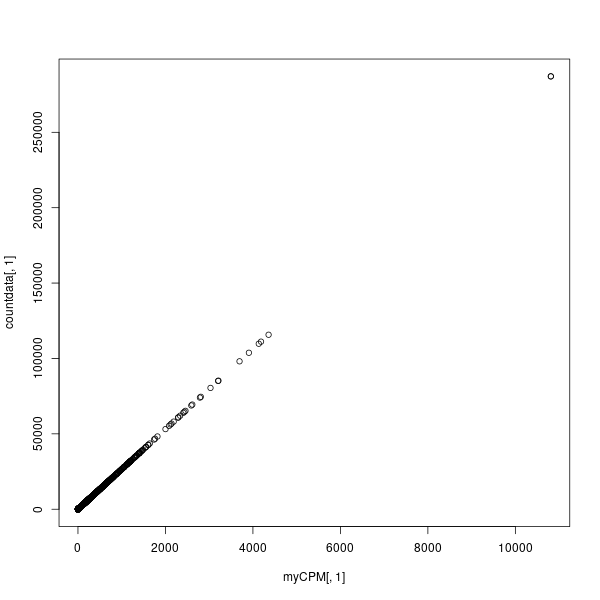

In [130]:
from IPython.display import Image
Image(filename='Plot1.CPMvsCountdata.png', width = 600, height = 600)

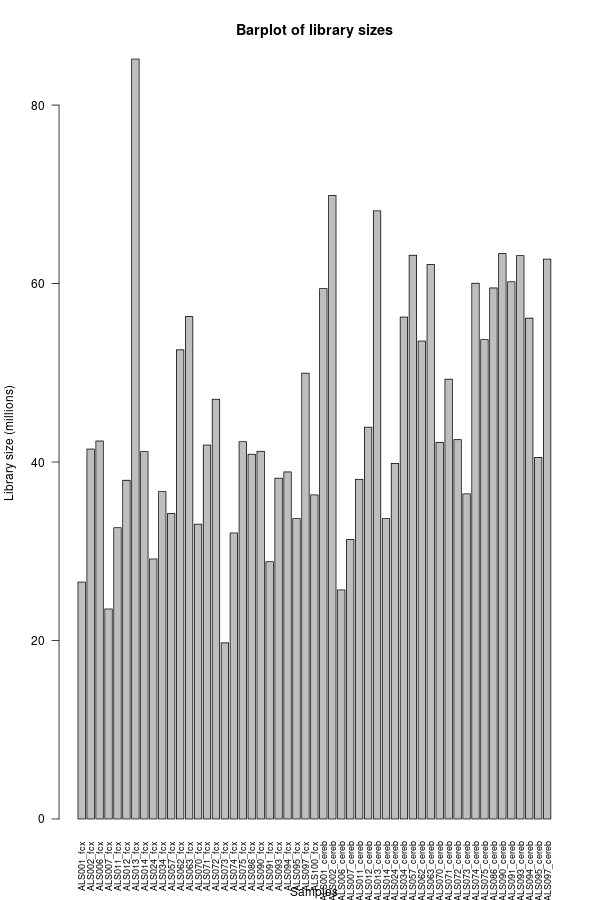

In [131]:
from IPython.display import Image
Image(filename='Plot2.Barplot.LibrarySize.png', width = 600, height = 600)

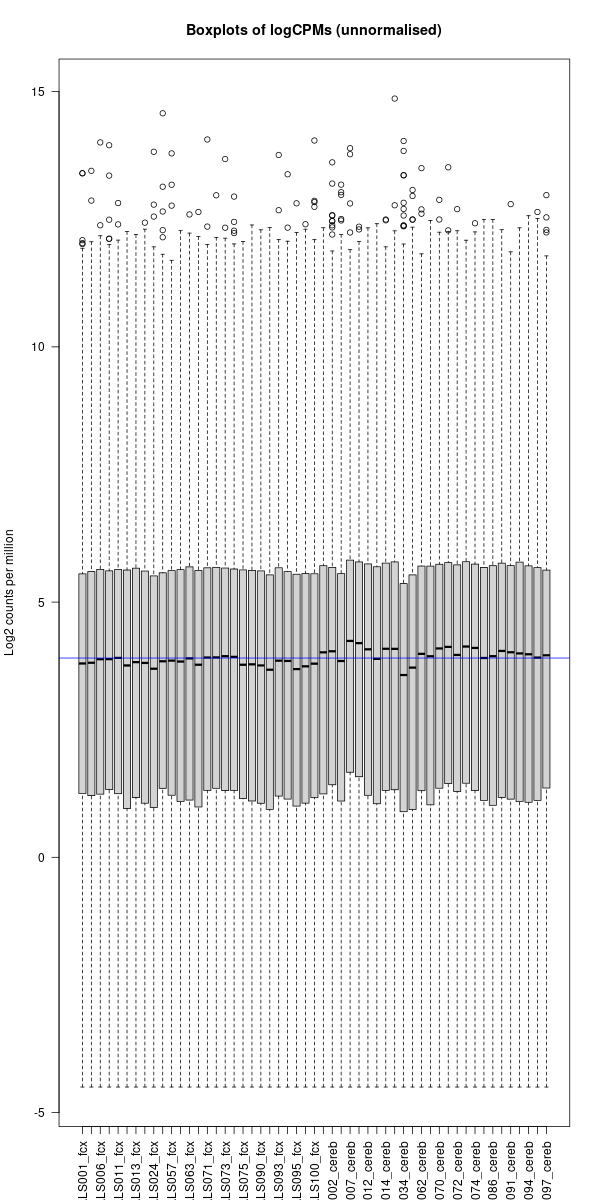

In [74]:
from IPython.display import Image
Image(filename='Plot3.Boxplot.logCPMs.Unnormalised.png', width = 600, height = 600)


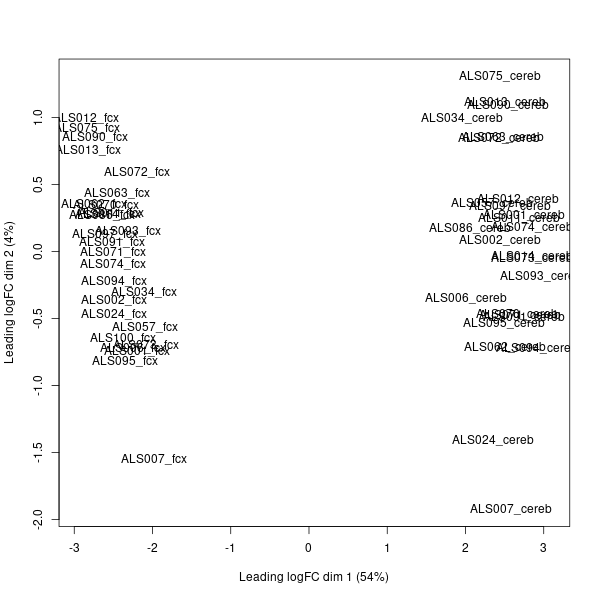

In [79]:
from IPython.display import Image
Image(filename='Plot4.MSD.General.png', width = 600, height = 600)


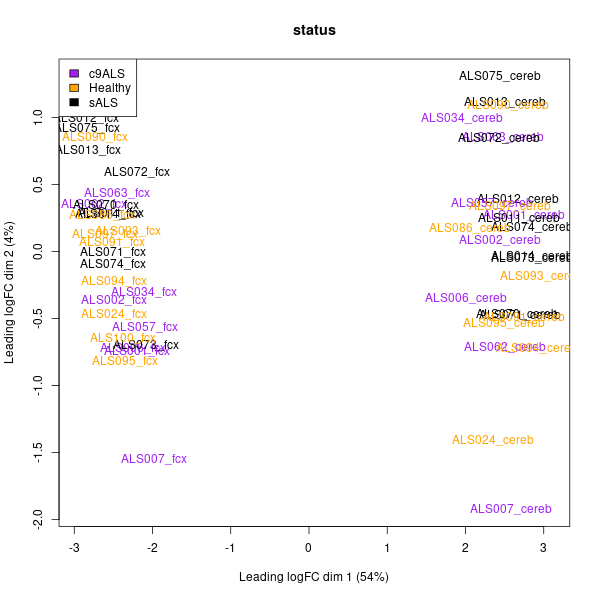

In [107]:
from IPython.display import Image
Image(filename='Plot4.1.MSD.Status.png', width = 600, height = 600)


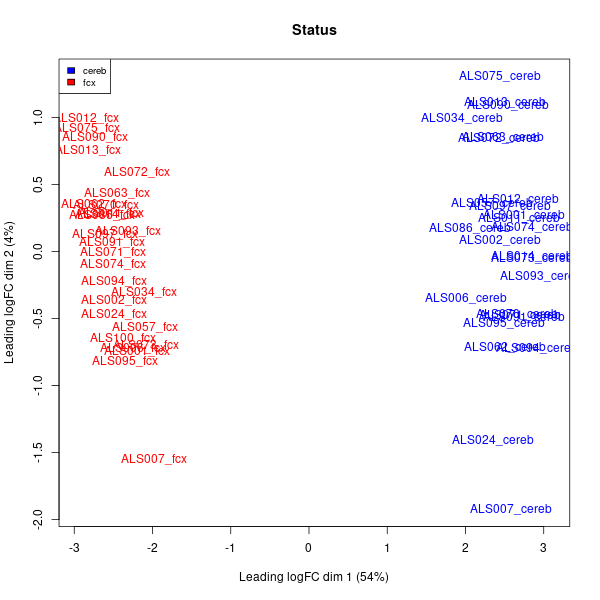

In [108]:
from IPython.display import Image
Image(filename='Plot4.2.MSD.Tissue.png', width = 600, height = 600)

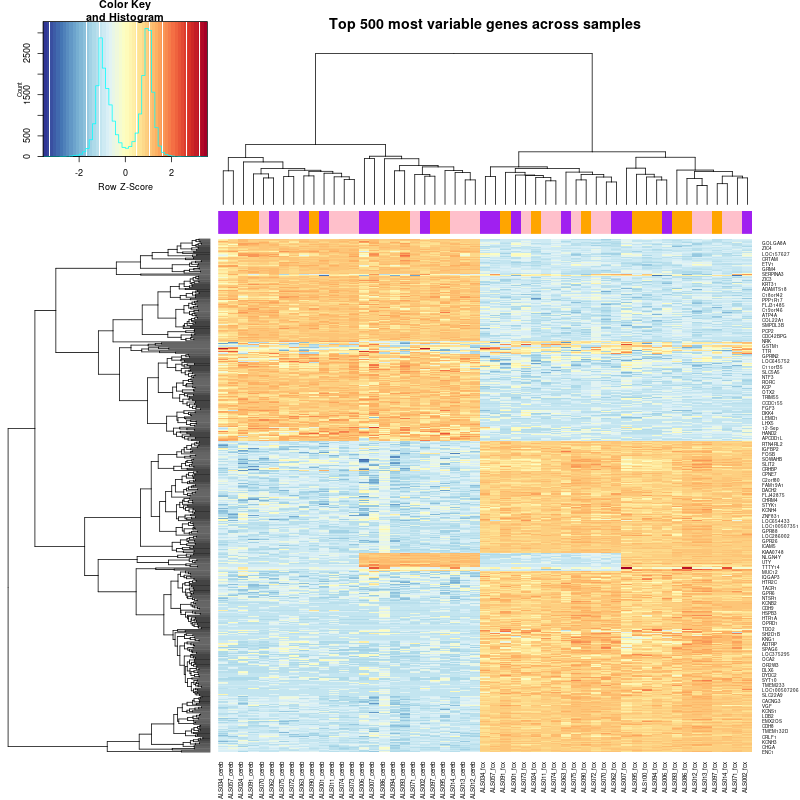

In [125]:
from IPython.display import Image
Image(filename='Plot5.Heatmap.png', width = 1200, height = 1200)

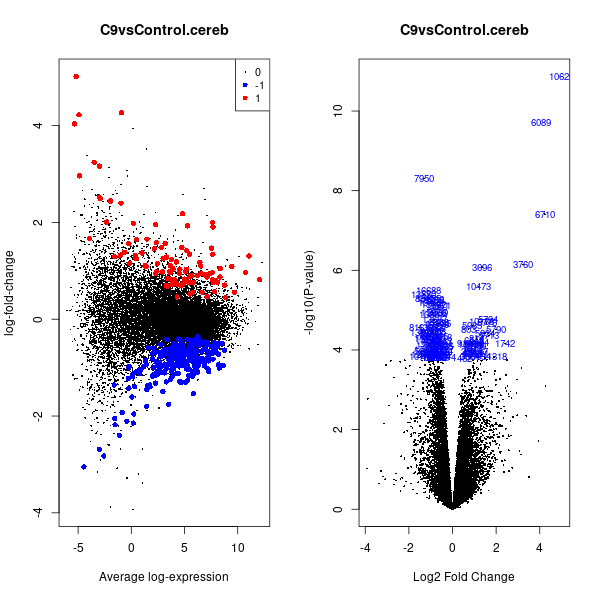

In [145]:
from IPython.display import Image
Image(filename='Plot.8.Significantgenes.png', width = 1200, height = 1200)

In [12]:
%%bash

module load R/4.1.0
R --vanilla --no-save

#if (!requireNamespace("BiocManager"))
#    install.packages("BiocManager")
#BiocManager::install(c("limma", "edgeR", "Glimma", "RColorBrewer", "NMF", "BiasedUrn"))

#load packages
library(data.table)
library(ggplot2)
library(cowplot)
library(svglite)
library(DESeq2)
library(GEOquery)
library(limma)
library(edgeR)
library(Glimma)
library(RColorBrewer)
library(tidyverse)
library(dplyr)
library(BiasedUrn)
library(NMF)

# Read the data into R
seqdata <- read.table("GSE67196_Petrucelli2015_ALS_genes.rawcount.txt.gz",header = T)
seqdata <- select(seqdata,-starts_with("chr"))

# Read the sample information into R
sampleinfo <- read.table("new.pheno.matrix.txt",header = T)

print(sampleinfo)

dim(seqdata)
head(seqdata)
head(sampleinfo)
dim(sampleinfo)


countdata <- seqdata[,-1]
# Look at the output
head(countdata)
countdata <- select(countdata, ALS001_cereb, ALS002_cereb,ALS062_cereb, ALS063_cereb)


names = seqdata$GeneID
length(names)

countdata.m <- as.matrix(countdata)
rownames(countdata.m) <- names
head(countdata.m)
countdata <- countdata.m
dim(countdata)

colnames(countdata)
sampleinfo$Sample_title



table(colnames(countdata)==sampleinfo$Sample_title)
#not in the same order but same names

y <- DGEList(countdata)
# have a look at y
y

names(y)
y$samples

group <- sampleinfo$group.onset
# Take a look
group

# Convert to factor
group <- factor(group)
# Take another look.
group

# Add the group information into the DGEList
y$samples$group <- group
y$samples


## Filtering lowly expressed genes
# Obtain CPMs
myCPM <- cpm(countdata)
# Have a look at the output
head(myCPM)

# Which values in myCPM are greater than 0.5?
thresh <- myCPM > 0.5
# This produces a logical matrix with TRUEs and FALSEs
head(thresh)

# Summary of how many TRUEs there are in each row
# There are 11433 genes that have TRUEs in all 12 samples.
table(rowSums(thresh))

# we would like to keep genes that have at least 2 TRUES in each row of thresh
keep <- rowSums(thresh) >= 2
summary(keep)


# Let's have a look and see whether our threshold of 0.5 does indeed correspond to a count of about 10-15
# We will look at the first sample



#pdf("Plot1.CPMvsCountdata.pdf",
#width=600, height=350)
#plot1 <- plot(myCPM[,1],countdata[,1])
#dev.off()

#png("Plot1.CPMvsCountdata.png",
#width=600, height=600)
#plot1 <- plot(myCPM[,1],countdata[,1])
#dev.off()

#Now that we’ve checked our filtering method we will filter the DGEList object
y <- y[keep, keep.lib.sizes=FALSE]

#### Quality control

#Library size and distribution plots
y$samples$lib.size

#plot2 <- barplot(y$samples$lib.size,names=colnames(y),las=2)
# Add a title to the plot
#title("Barplot of library sizes")

# we can also adjust the labelling if we want
#pdf("Plot2.Barplot.LibrarySize.pdf",
#width=600, height=350)

#barplot(y$samples$lib.size/1e06, names=colnames(y), las=2, ann=FALSE, cex.names=0.75)
#mtext(side = 1, text = "Samples", line = 4)
#mtext(side = 2, text = "Library size (millions)", line = 3)
#title("Barplot of library sizes")

#dev.off()

#png("Plot2.Barplot.LibrarySize.png",
#width=600, height=900)

#barplot(y$samples$lib.size/1e06, names=colnames(y), las=2, ann=FALSE, cex.names=0.75)
#mtext(side = 1, text = "Samples", line = 4)
#mtext(side = 2, text = "Library size (millions)", line = 3)
#title("Barplot of library sizes")
#dev.off()

# Get log2 counts per million
logcounts <- cpm(y,log=TRUE)

#pdf("Plot3.Boxplot.logCPMs.Unnormalised.pdf",
#width=600, height=350)
# Check distributions of samples using boxplots
#boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2)
# Let's add a blue horizontal line that corresponds to the median logCPM
#abline(h=median(logcounts),col="blue")
#title("Boxplots of logCPMs (unnormalised)")
#dev.off()


#png("Plot3.Boxplot.logCPMs.Unnormalised.png",
#width=600, height=1200)
# Check distributions of samples using boxplots
#boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2)
# Let's add a blue horizontal line that corresponds to the median logCPM
#abline(h=median(logcounts),col="blue")
#title("Boxplots of logCPMs (unnormalised)")
#dev.off()

#png("Plot4.MSD.General.png", width=600, height=600)
#plotMDS(y)
#dev.off()

#pdf("Plot4.MSD.General.pdf", width=600, height=600)
#plotMDS(y)
#dev.off()


# Let's set up colour schemes for CellType
# How many cell types and in what order are they stored?
head(sampleinfo)
table(sampleinfo$group.onset)
sampleinfo$group.onset <- as.factor(sampleinfo$group.onset)
levels(sampleinfo$group.onset)

col.onset <- c("purple","orange")[sampleinfo$group.onset]
data.frame(sampleinfo$group.onset,col.onset)

png("Plot4.1.MSD.onset.c9only.png", width=600, height=600)
plotMDS(y,col=col.onset)
legend("topleft",fill=c("purple","orange"),legend=levels(sampleinfo$group.onset))
title("Onset group")
dev.off()



# We estimate the variance for each row in the logcounts matrix
var_genes <- apply(logcounts, 1, var)
head(var_genes)

# Get the gene names for the top 500 most variable genes
select_var <- names(sort(var_genes, decreasing=TRUE))[1:500]
head(select_var)

# Subset logcounts matrix
highly_variable_lcpm <- logcounts[select_var,]
dim(highly_variable_lcpm)

head(highly_variable_lcpm)

## Get some nicer colours

mypalette <- brewer.pal(11,"RdYlBu")
morecols <- colorRampPalette(mypalette)
# Set up colour vector for celltype variable
col.cell <- c("purple","orange")[sampleinfo$group.onset]
print(sampleinfo)
# Plot the heatmap
library(gplots)
png("Plot5.Heatmap.onset.c9only.png", width=800, height=800)
heatmap.2(highly_variable_lcpm,col=rev(morecols(50)),trace="none", main="Top 500 most variable genes across samples",ColSideColors=col.cell,scale="row")
dev.off()

#### Normalization
# Apply normalisation to DGEList object
y <- calcNormFactors(y)
y$samples

save(group,y,logcounts,sampleinfo,file="day1objects.onset.c9only.png.Rdata")

### DEG
group
# Specify a design matrix without an intercept term
design <- model.matrix(~ 0 + group)
design

## Make the column names of the design matrix a bit nicer
colnames(design) <- levels(group)
design
#png("Plot6.Voom.png", width=600, height=600)

#par(mfrow=c(1,1))
v <- voom(y,design,plot = TRUE)
#dev.off()

v

# What is contained in this object?
names(v)

#png("Plot.7.1.Boxplot.Unnormalized.png", width=600, height=600)
#par(mfrow=c(1,2))
#boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2,main="Unnormalised logCPM")
## Let's add a blue horizontal line that corresponds to the median logCPM
#abline(h=median(logcounts),col="blue")
#dev.off()
#png("Plot.7.2.Boxplot.Normalized.png", width=600, height=600)
#boxplot(v$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
## Let's add a blue horizontal line that corresponds to the median logCPM
#abline(h=median(v$E),col="blue")
#dev.off()

# Fit the linear model
fit <- lmFit(v)

cont.matrix <- makeContrasts(C9oldvsC9young=old - young,levels=design)
cont.matrix

fit.cont <- contrasts.fit(fit, cont.matrix)

fit.cont <- eBayes(fit.cont)

dim(fit.cont)

summa.fit <- decideTests(fit.cont)
summary(summa.fit)


result <- topTable(fit.cont, number = 150, adjust = "BH", p.value = 1, lfc = 0, coef = "C9oldvsC9young")
head(result)
write.table(result, "topTable.C9oldvsC9young.cereb.tab", quote = F, sep= "\t", col.names = T, row.names = T)

# We want to highlight the significant genes. We can get this from decideTests.




R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> 
> #if (!requireNamespace("BiocManager"))
> #    install.packages("BiocManager")
> #BiocManager::install(c("limma", "edgeR", "Glimma", "RColorBrewer", "NMF", "BiasedUrn"))
> 
> #load packages
> library(data.table)
> library(ggplot2)
> library(cowplot)
> library(svglite)
> library(DESeq2)
> library(GEOquery

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0974 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0974 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduc

In [2]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
library(Hmisc)
library(signatureSearch)
library(ExperimentHub); library(rhdf5)
eh <- ExperimentHub()
cmap <- eh[["EH3223"]]; cmap_expr <- eh[["EH3224"]]
lincs <- eh[["EH3226"]]; lincs_expr <- eh[["EH3227"]]
h5ls(lincs)
up <- fread("Nick.Up.Bonferroni.C9vsControl.txt", header = F)
upset = as.character(up$V1)
dn <- fread("Nick.Down.Bonferroni.C9vsControl.txt", header = F)
downset = as.character(dn$V1)


#### NYGC, motor cortex

#CMAP method
qsig_cmap <- qSig(query = list(upset=upset, downset=downset), 
                  gess_method="CMAP", refdb=lincs)
                  
cmap <- gess_cmap(qSig=qsig_cmap, chunk_size=5000, workers=1)
cmap
df_cmap  = as.data.frame(cmap@result)
write.csv(df_cmap, "NYGC.motorcortex.cmapmethod.lincs.DGEsBon.ALL.csv")
drugs <- fread("drugs.txt", header = F)
colnames(drugs) <- "pert"
head(drugs)
merged_cmap <- merge(df_cmap, drugs, by = "pert")
write.csv(merged_cmap, "NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.csv")

#LINCS method using the same pertub. database and UP/DN regulated genes
qsig_lincs <- qSig(query = list(upset=upset, downset=downset), 
                   gess_method="LINCS", refdb=lincs)
lincsm <- gess_lincs(qsig_lincs, sortby="NCS", tau=FALSE, workers=1)
result(lincsm)
df_lincs  = as.data.frame(lincsm@result)
write.csv(df_lincs, "NYGC.motorcortex.lincsmethod.DGEsBon.ALL.csv")
merged_lincs <- merge(df_cmap, drugs, by = "pert")
write.csv(merged_lincs, "NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv")



### Prudencio et al., 2015; Cerebellum 
up <- fread("Up.Prudencio.C9vsControl.Cereb.txt", header = F)
upset = as.character(up$V1)
dn <- fread("Dn.Prudencio.C9vsControl.Cereb.txt", header = F)
downset = as.character(dn$V1)


#CMAP method
qsig_cmap <- qSig(query = list(upset=upset, downset=downset), 
                  gess_method="CMAP", refdb=lincs)
                  
cmap <- gess_cmap(qSig=qsig_cmap, chunk_size=5000, workers=1)
cmap
df_cmap  = as.data.frame(cmap@result)
write.csv(df_cmap, "Prudencio.cerebellum.cmapmethod.lincs.DGEsFDR.ALL.csv")
drugs <- fread("drugs.txt", header = F)
colnames(drugs) <- "pert"
head(drugs)
merged_cmap <- merge(df_cmap, drugs, by = "pert")
write.csv(merged_cmap, "Prudencio.cerebellum.cmapmethod.lincs.DGEsFDR.onlyNOMINATED.csv")

#LINCS method using the same pertub. database and UP/DN regulated genes
qsig_lincs <- qSig(query = list(upset=upset, downset=downset), 
                   gess_method="LINCS", refdb=lincs)
lincsm <- gess_lincs(qsig_lincs, sortby="NCS", tau=FALSE, workers=1)
result(lincsm)
df_lincs  = as.data.frame(lincsm@result)
write.csv(df_lincs, "Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv")
merged_lincs <- merge(df_cmap, drugs, by = "pert")
write.csv(merged_lincs, "Prudencio.cerebellum.lincsmethod.DGEsFDR.onlyNOMINATED.csv")








R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)
> library(tidyverse)
> library(dplyr)
> library(Hmisc)
> library(signatureSearch)
> library(ExperimentHub); library(rhdf5)
> eh <- ExperimentHub()
> cmap <- eh[["EH3223"]]; cmap_expr <- eh[["EH3224"]]
> lincs <- eh[["EH3226"]]; lincs_expr <- eh[["EH3227"]]
> h5ls(lincs

[-] Unloading gcc  9.2.0  ... 
[-] Unloading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading openmpi 4.0.5  for GCC 9.2.0 
[-] Unloading ImageMagick  7.0.8  on cn0886 
[-] Unloading HDF5  1.10.4 
[-] Unloading NetCDF 4.7.4_gcc9.2.0 
[-] Unloading pandoc  2.16.2  on cn0886 
[-] Unloading pcre2 10.21  ... 
[-] Unloading R 4.1.0 
[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0886 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0886 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 

The following have been reloaded with a version change:
  1) R/4.1 => R/4.1.0

Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

   

In [1]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(RColorBrewer)

data <- fread("NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.csv", header = T)
head(data)

p <- ggplot(data, aes(pert, raw_score))
p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(raw_score=mean(raw_score))
ggplot(data = data) +
  aes((x=reorder(pert,-raw_score)), y = raw_score) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#259dbe") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
ggsave("NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)
  
  
  data <- fread("Prudencio.cerebellum.cmapmethod.lincs.DGEsFDR.onlyNOMINATED.csv", header = T)
head(data)

p <- ggplot(data, aes(pert, raw_score))
p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(raw_score=mean(raw_score))
ggplot(data = data) +
  aes((x=reorder(pert,-raw_score)), y = raw_score) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#9f7da3") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
ggsave("Prudencio.cerebellum.cmapmethod.lincs.DGEsFDR.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(tidyverse)
> library(ggplot2)
> library(dplyr)
> library(RColorBrewer)
> 
> data <- fread("NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.csv", header = T)
> head(data)
   V1        pert     PCID cell   type trend  raw_score scaled_score N_upset
1:  1 acamprosate 7370

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0965 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0965 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.1.0     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()   masks data.table::between()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::first()     masks data.table::first()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::last()      masks data.table::last()
✖ purrr::transpose() masks data.table::transpo

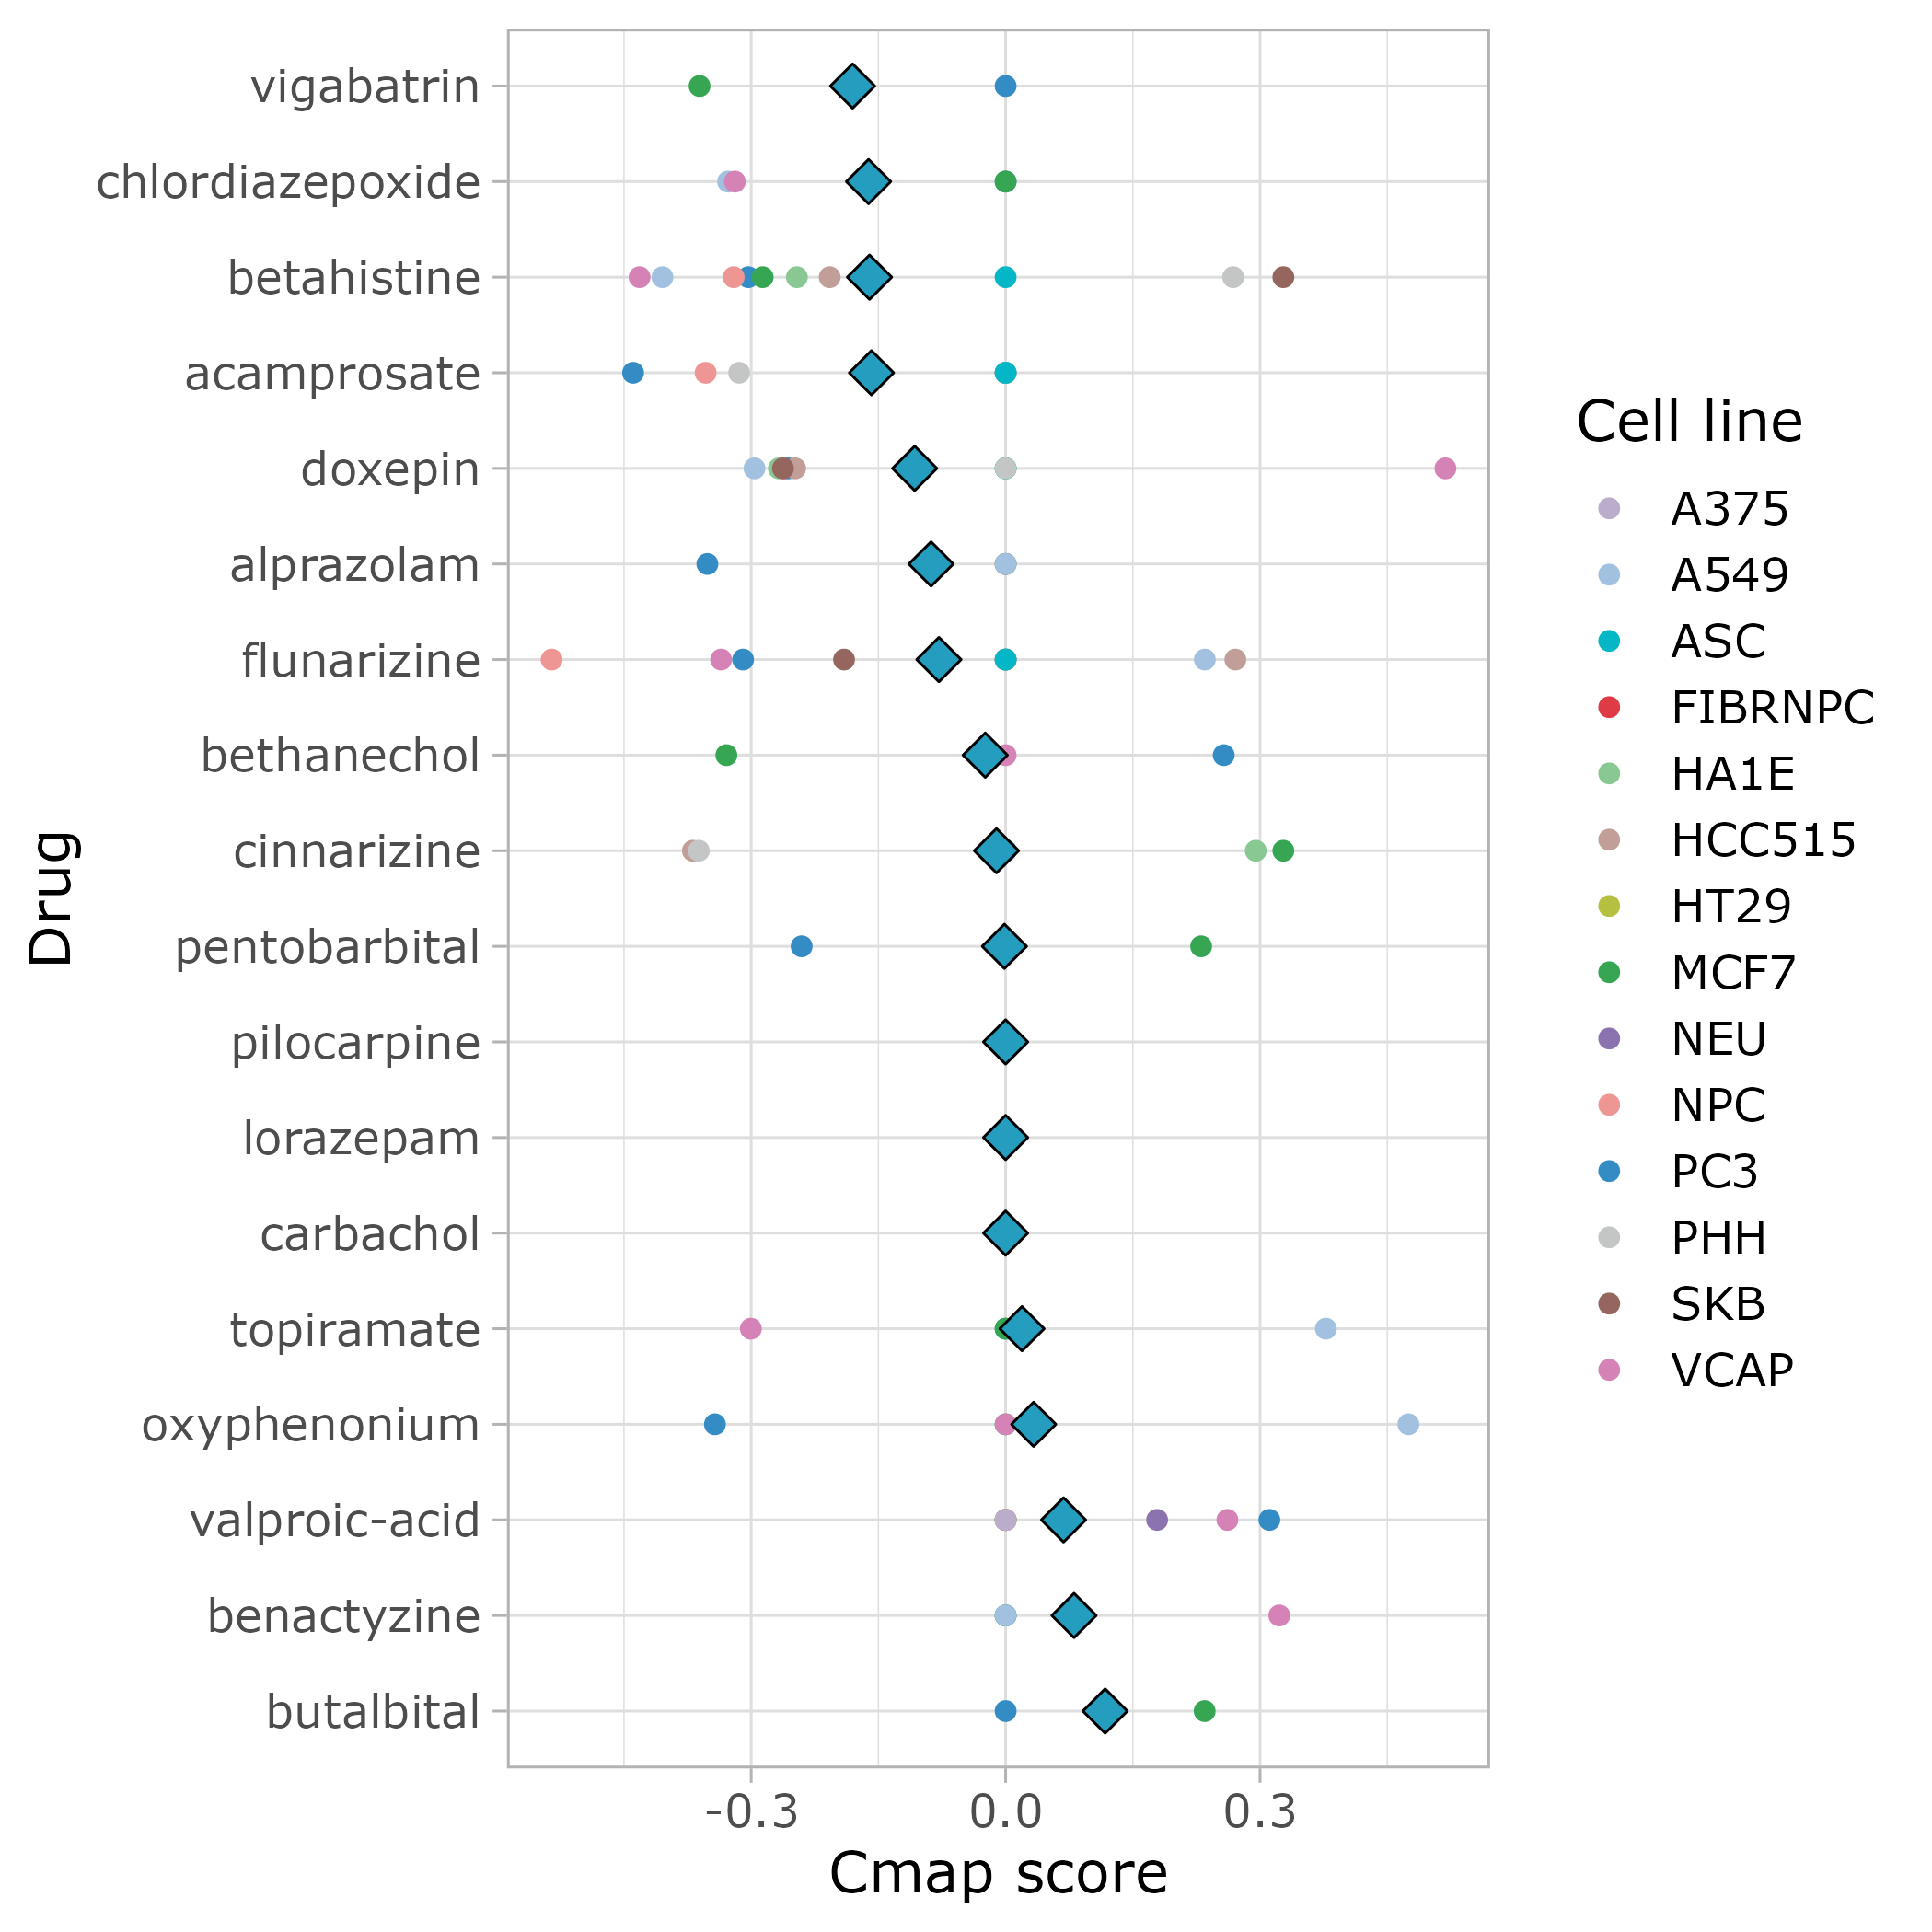

In [2]:
from IPython.display import Image
Image(filename='NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.png', width = 600, height = 600)

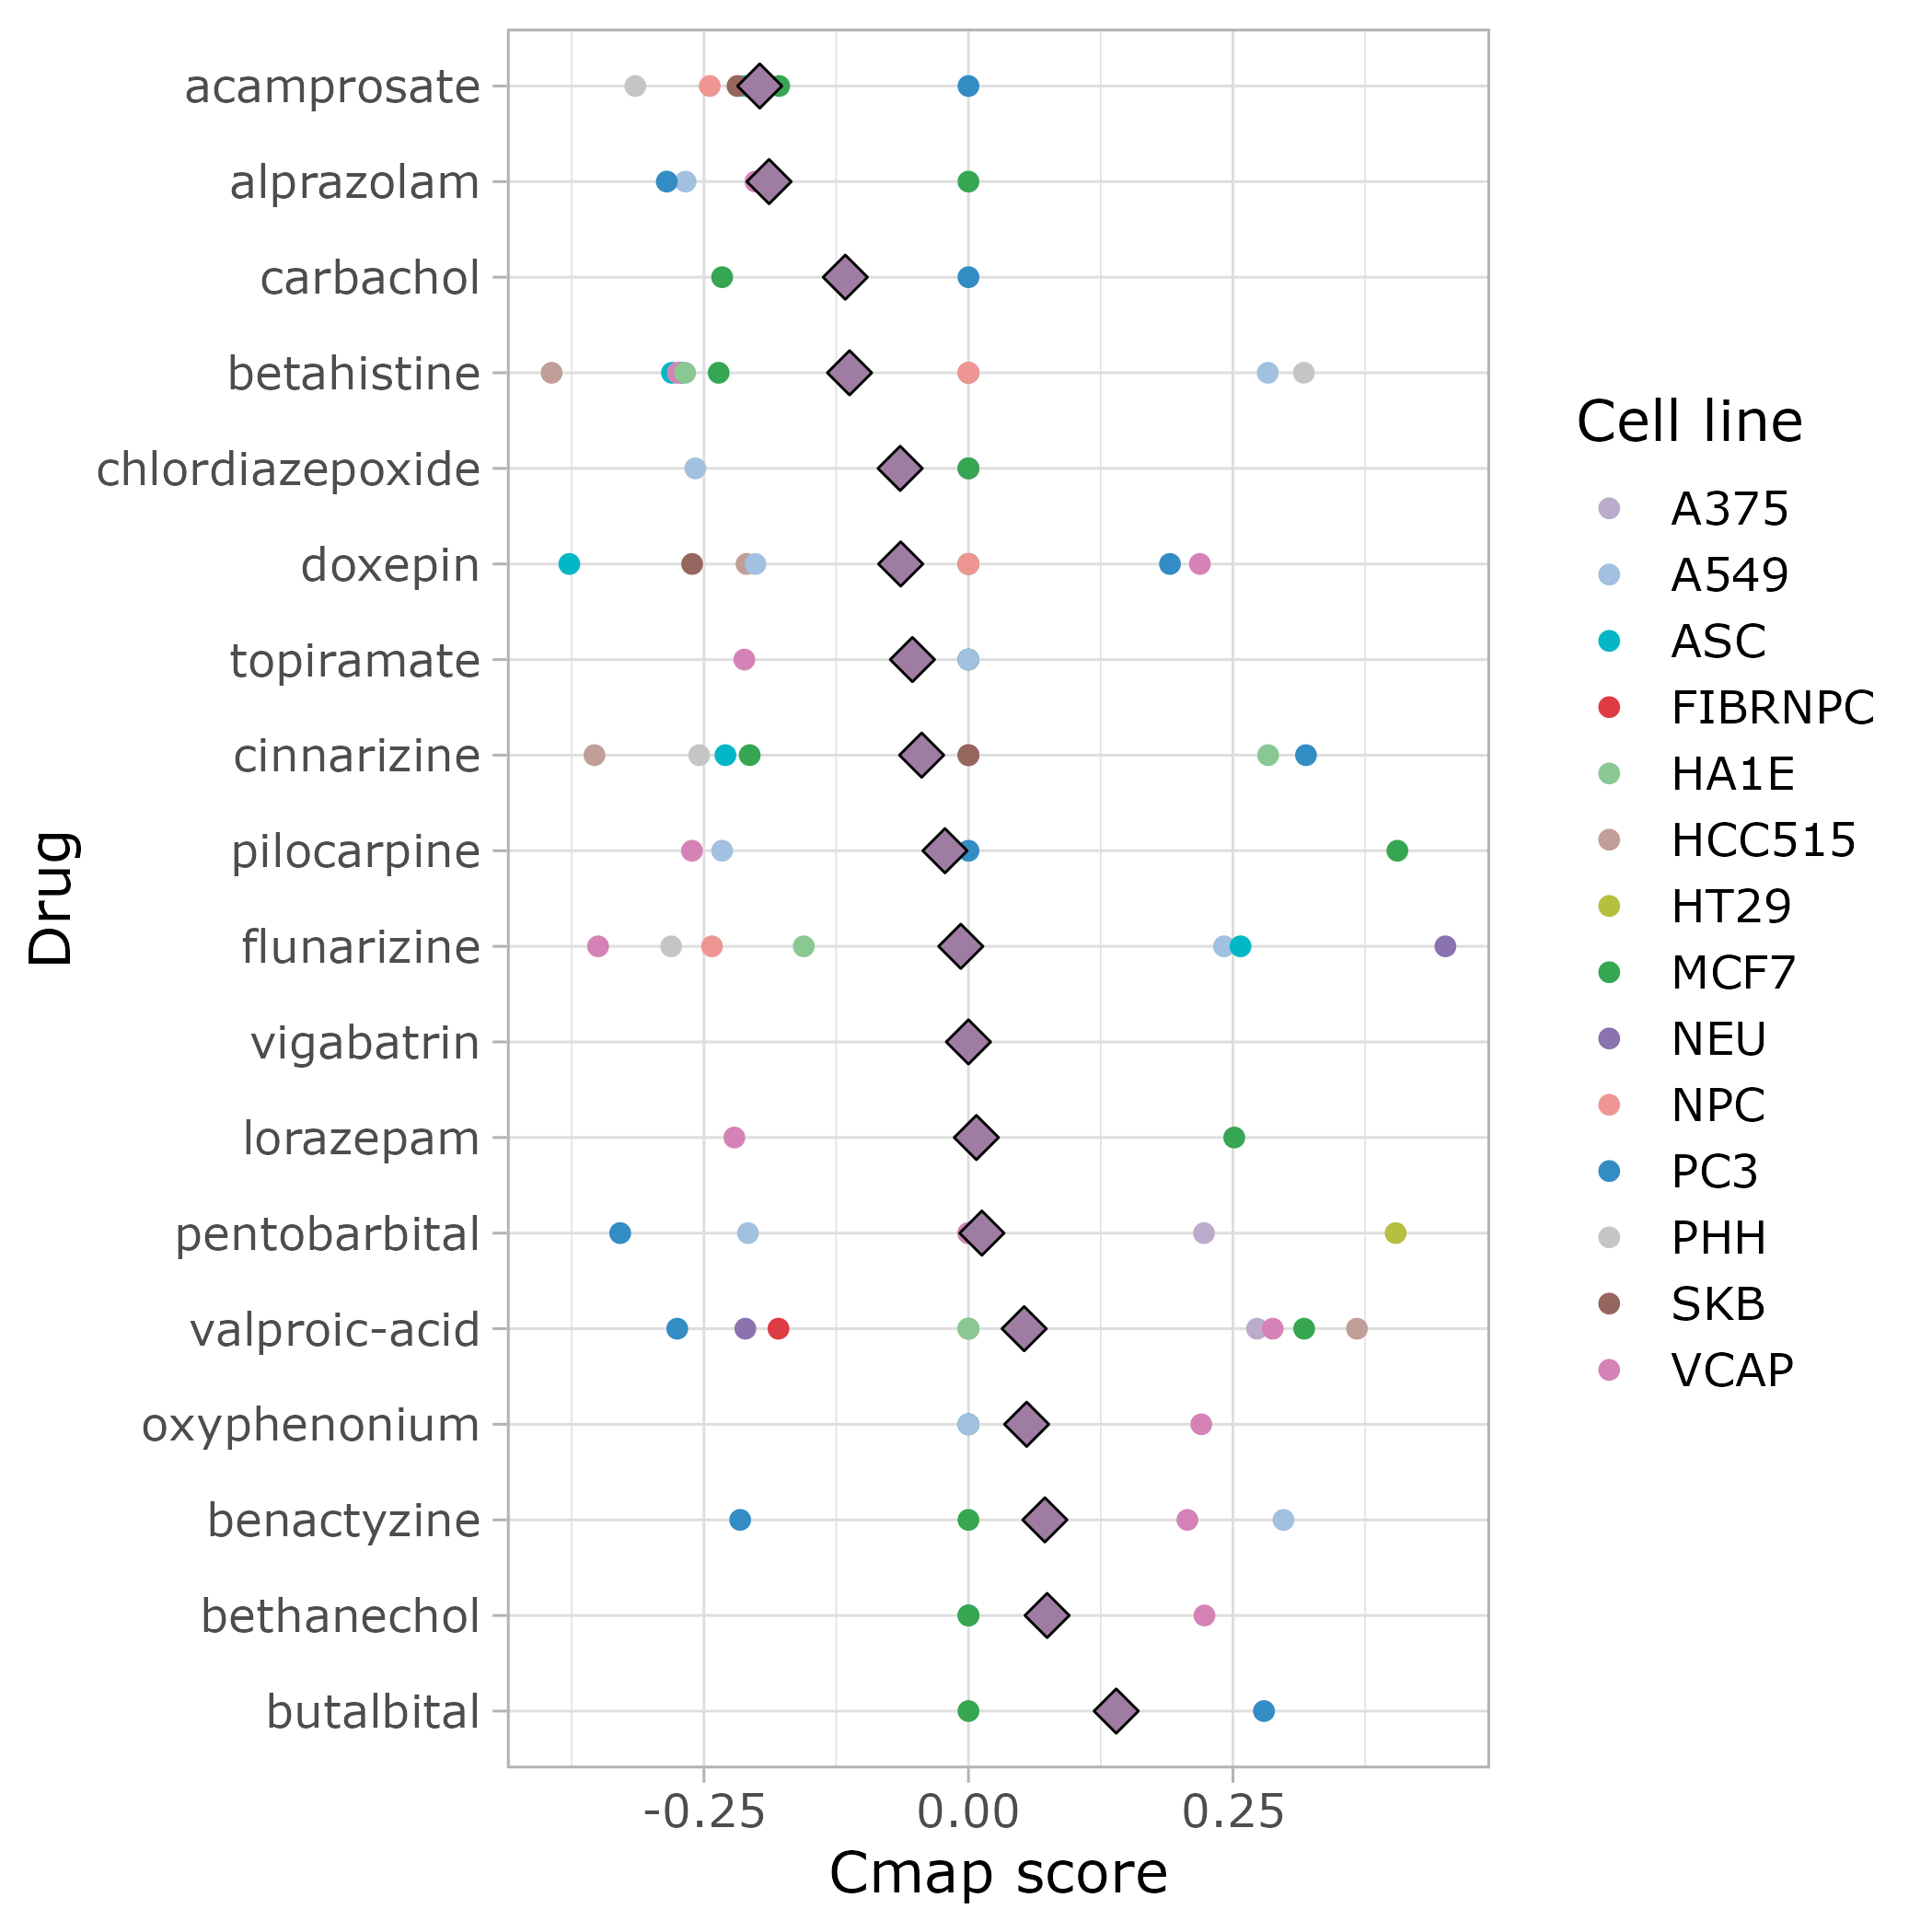

In [3]:
from IPython.display import Image
Image(filename='Prudencio.cerebellum.cmapmethod.lincs.DGEsFDR.onlyNOMINATED.png', width = 600, height = 600)

In [4]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(RColorBrewer)

data <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv", header = T)
head(data)

p <- ggplot(data, aes(pert, raw_score))
p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(raw_score=mean(raw_score))
ggplot(data = data) +
  aes((x=reorder(pert,-raw_score)), y = raw_score) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#259dbe") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
ggsave("NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)
  
  
  data <- fread("Prudencio.cerebellum.lincsmethod.DGEsFDR.onlyNOMINATED.csv", header = T)
head(data)

p <- ggplot(data, aes(pert, raw_score))
p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(raw_score=mean(raw_score))
ggplot(data = data) +
  aes((x=reorder(pert,-raw_score)), y = raw_score) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#9f7da3") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
ggsave("Prudencio.cerebellum.lincsmethod.lincs.DGEsFDR.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)




R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(tidyverse)
> library(ggplot2)
> library(dplyr)
> library(RColorBrewer)
> 
> data <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv", header = T)
> head(data)
   V1        pert     PCID cell   type trend  raw_score scaled_score N_upset
1:  1 acamprosate 73707392 

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0965 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0965 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.1.0     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()   masks data.table::between()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::first()     masks data.table::first()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::last()      masks data.table::last()
✖ purrr::transpose() masks data.table::transpo

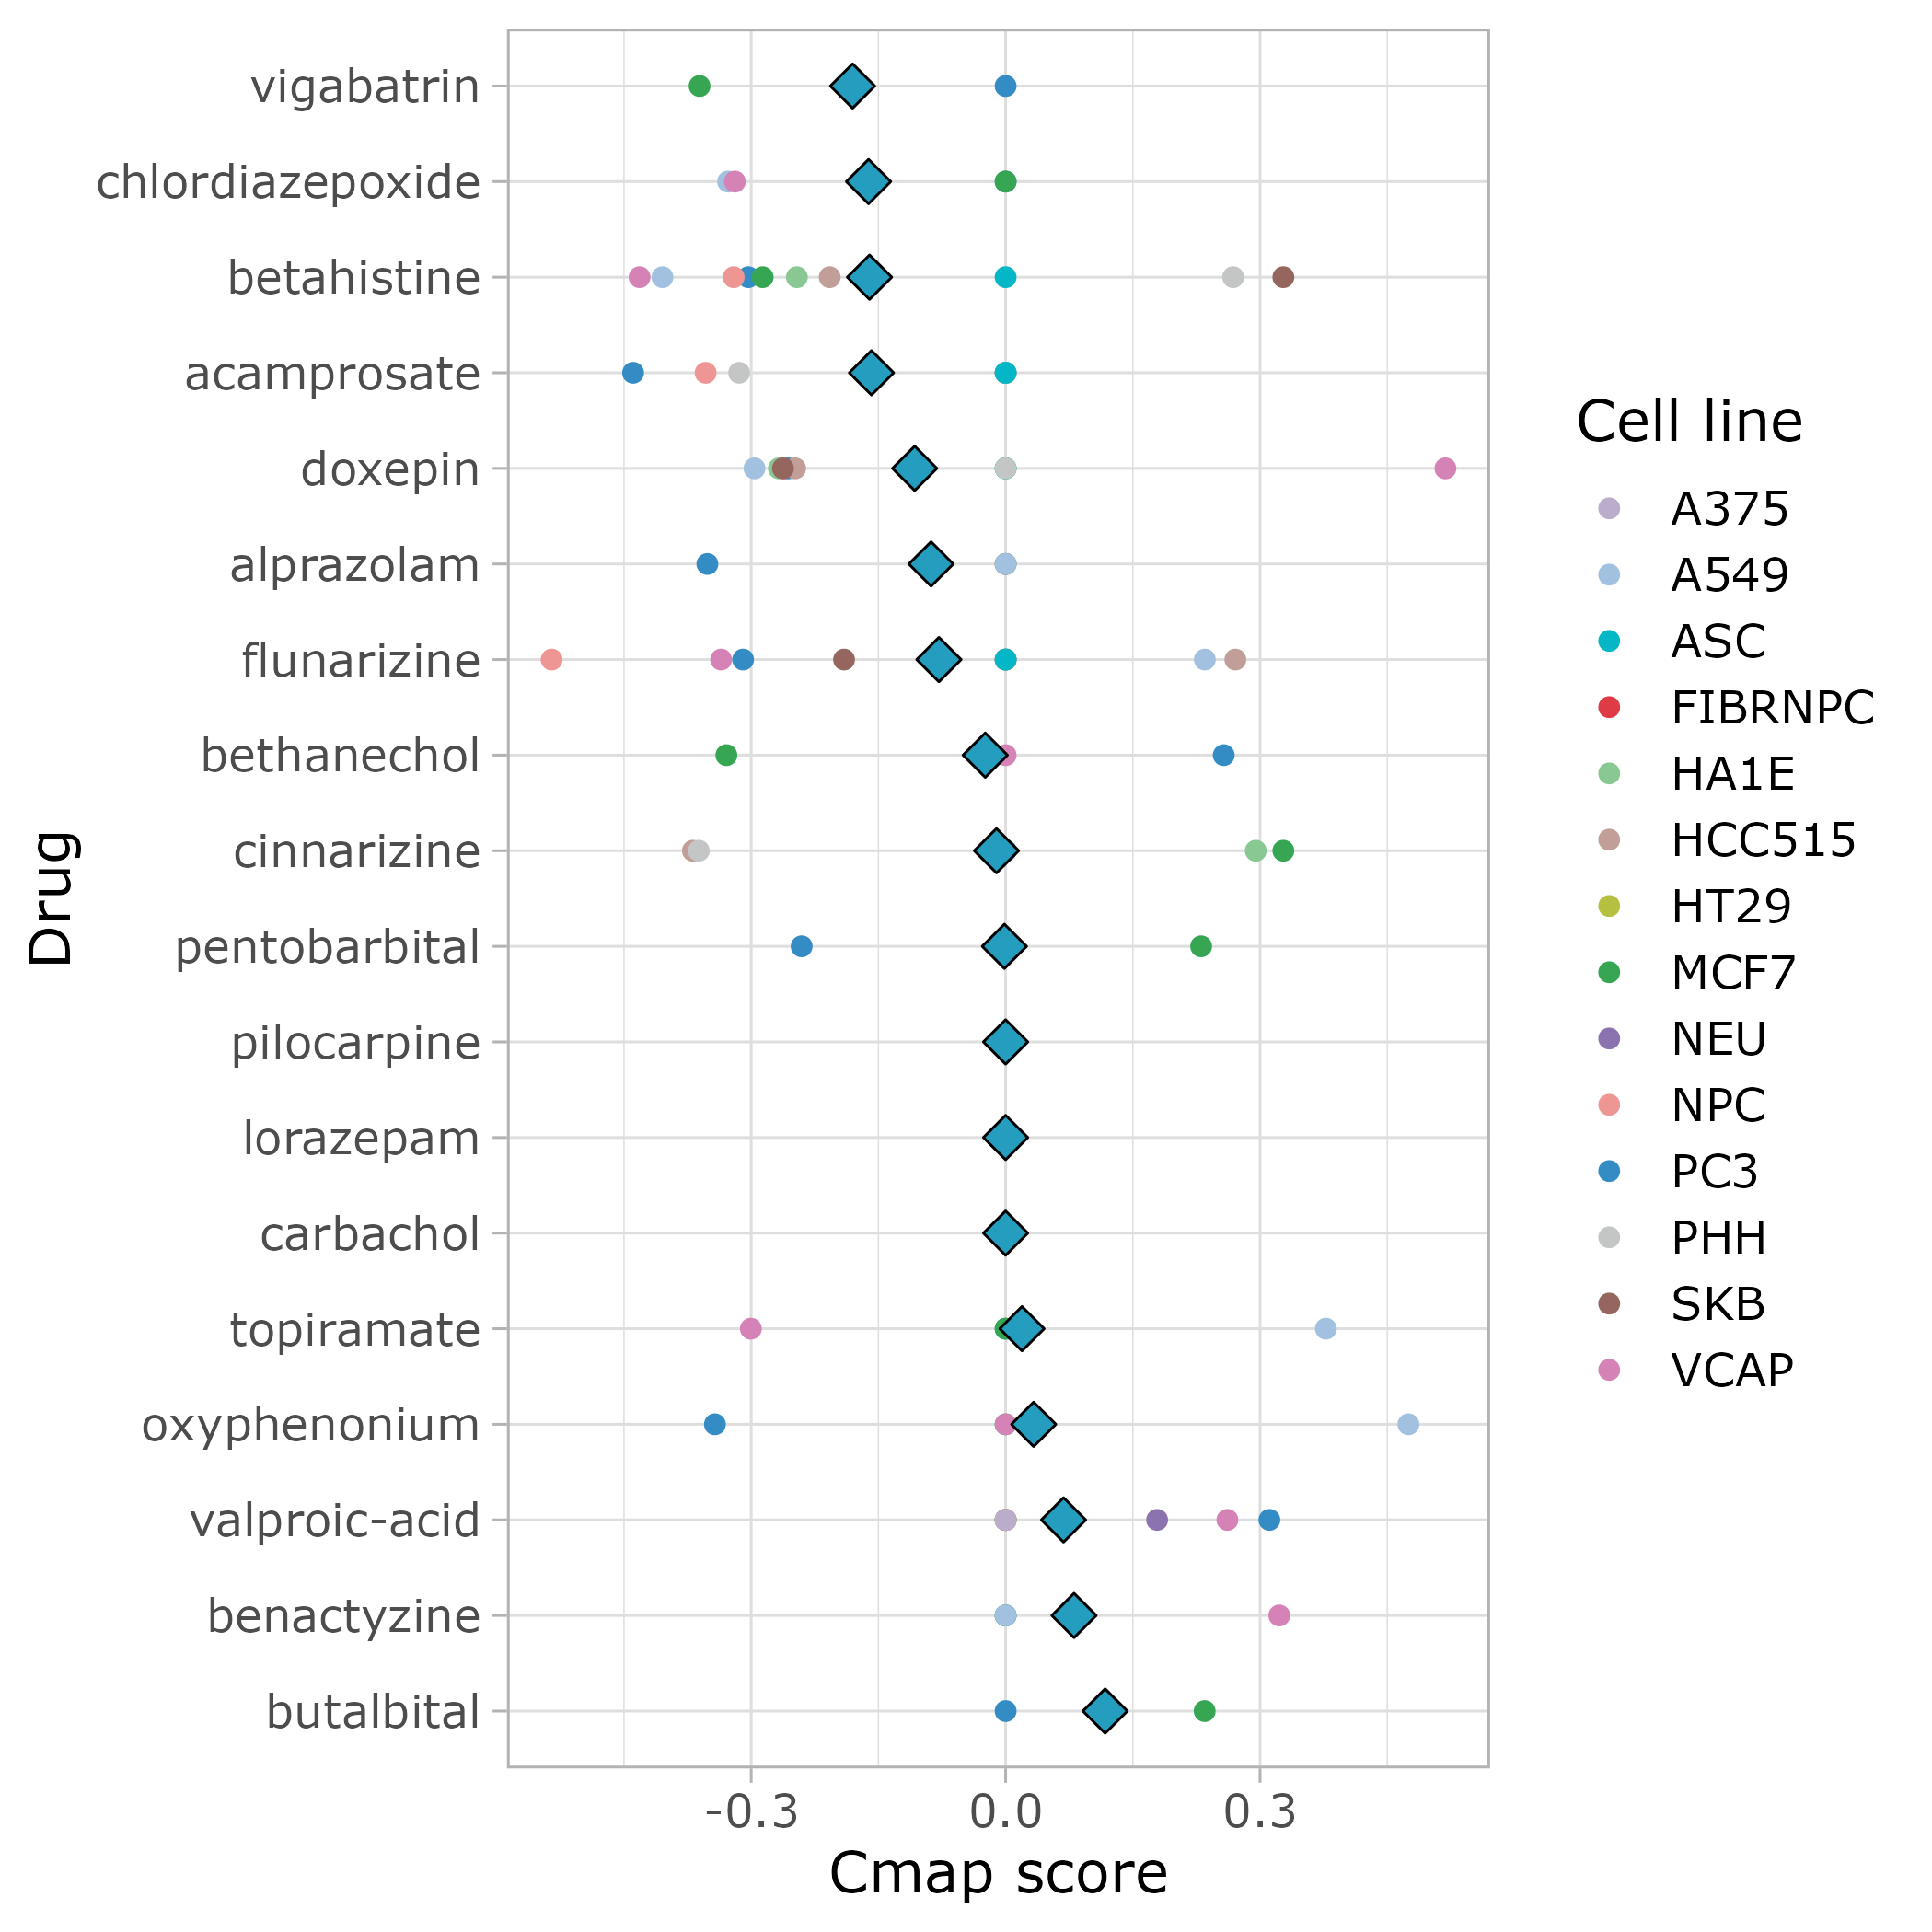

In [2]:
from IPython.display import Image
Image(filename='NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png', width = 600, height = 600)

In [3]:
%%bash
head NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv

"","pert","PCID","cell","type","trend","raw_score","scaled_score","N_upset","N_downset","t_gn_sym"
"1","acamprosate","73707392","PC3","trt_cp","down",-0.43926632820552,-0.633344790359807,50,34,"GABRA2; GABRA3; GABRA4; GABRA5; GABRA6; GABRB1; GABRB2; GABRB3; GABRD; GABRE; GABRG1; GABRG2; GABRG3; GABRP; GABRQ; GRIN1; GRIN2A; GRIN2B; GRIN2C; GRIN2D; GRIN3A; GRIN3B; GRM5"
"2","acamprosate","73707392","SKB","trt_cp","up",0,0,50,34,"GABRA2; GABRA3; GABRA4; GABRA5; GABRA6; GABRB1; GABRB2; GABRB3; GABRD; GABRE; GABRG1; GABRG2; GABRG3; GABRP; GABRQ; GRIN1; GRIN2A; GRIN2B; GRIN2C; GRIN2D; GRIN3A; GRIN3B; GRM5"
"3","acamprosate","73707392","MCF7","trt_cp","up",0,0,50,34,"GABRA2; GABRA3; GABRA4; GABRA5; GABRA6; GABRB1; GABRB2; GABRB3; GABRD; GABRE; GABRG1; GABRG2; GABRG3; GABRP; GABRQ; GRIN1; GRIN2A; GRIN2B; GRIN2C; GRIN2D; GRIN3A; GRIN3B; GRM5"
"4","acamprosate","73707392","PHH","trt_cp","down",-0.314185880062603,-0.45300078236172,50,34,"GABRA2; GABRA3; GABRA4; GABRA5; GABRA6; GABRB1; GABRB2; GAB

In [20]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
library(Hmisc)


lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.012522.csv", header = T)
head(lincs)
drugs <- fread("drugs.txt", header = F)
colnames(drugs)<- "pert"
merged_lincs <- merge(lincs, drugs, by = "pert")
write.csv(merged_lincs, "NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.012522.csv")
head(merged_lincs)
#############

data <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.012522.csv", header = T)
data$V1 = NULL


p <- ggplot(data, aes(pert, NCS))

p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(NCS=mean(NCS))
ggplot(data = data) +
  aes((x=reorder(pert,-NCS)), y = NCS) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#259dbe") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
  
ggsave("NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)
 

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0939 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0939 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)


Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges

Attaching package: ‘IRanges’

The following objec

> library(tidyverse)


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.1.1     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()    masks data.table::between()
✖ dplyr::collapse()   masks IRanges::collapse()
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()       masks IRanges::desc()
✖ tidyr::expand()     masks S4Vectors::expand()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::first()      masks S4Vectors::first(), data.table::first()
✖ dplyr::lag()        masks stats::lag()
✖ dplyr::last()       masks data.table::last()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()     masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()     masks S4Vectors::rename()
✖ dplyr::select()     masks AnnotationDbi:

...

> 
> 
> lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.012522.csv", header = T)
> head(lincs)
   V1              pert     PCID cell   type trend       WTCS    WTCS_Pval
1:  1     BRD-K91987625  5932959 A549 trt_cp    up  0.5382641 2.010553e-05
2:  2 dipropyl-dopamine NotFound HA1E trt_cp    up  0.5243727 2.071479e-05
3:  3     BRD-K82462389 54638747 A375 trt_cp    up  0.5194742 2.093238e-05
4:  4     BRD-K84797952 60185246 A549 trt_cp  down -0.5299112 2.045368e-05
5:  5        rimexolone 73707479 VCAP trt_cp  down -0.5329701 2.032313e-05
6:  6       ALW-II-38-3 24880028  NPC trt_cp  down -0.5409953 1.997498e-05
       WTCS_FDR       NCS       NCSct N_upset N_downset
1: 0.0004191783  1.832741  0.00000000      50        34
2: 0.0004191783  1.810713  0.59492187      50        34
3: 0.0004191783  1.781560  0.00000000      50        34
4: 0.0004191783 -1.770434 -1.06572877      50        34
5: 0.0004191783 -1.766597 -0.03115464      50        34
6: 0.0004191783 -1.759245  0.028244

Saving 7 x 7 in image


>   
> #########
> data <- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv", header = T)
> head(data)
   V1              pert     PCID cell   type trend       WTCS    WTCS_Pval
1:  1         radicicol  5311380  NEU trt_cp    up  0.5281018 2.054072e-05
2:  2     BRD-K03651937 44507986 VCAP trt_cp    up  0.5104227 2.132405e-05
3:  3     BRD-K22330909 60185012  PC3 trt_cp  down -0.4888264 2.223794e-05
4:  4   oxyphenbutazone     4641  NEU trt_cp    up  0.5040824 2.158516e-05
5:  5 BCI-hydrochloride  5475586 VCAP trt_cp    up  0.4943454 2.202035e-05
6:  6     BRD-K21374126 54651250 A375 trt_cp    up  0.4843088 2.245553e-05
      WTCS_FDR       NCS      NCSct N_upset N_downset
1: 0.000523335  1.847356  1.3680741      40        54
2: 0.000523335  1.810754  0.9445695      40        54
3: 0.000523335 -1.764001 -1.1818809      40        54
4: 0.000523335  1.763333  0.7934381      40        54
5: 0.000523335  1.753719  0.4903075      40        54
6: 0.000523335  1.741668  0.9648979     

Saving 7 x 7 in image


>   
> 


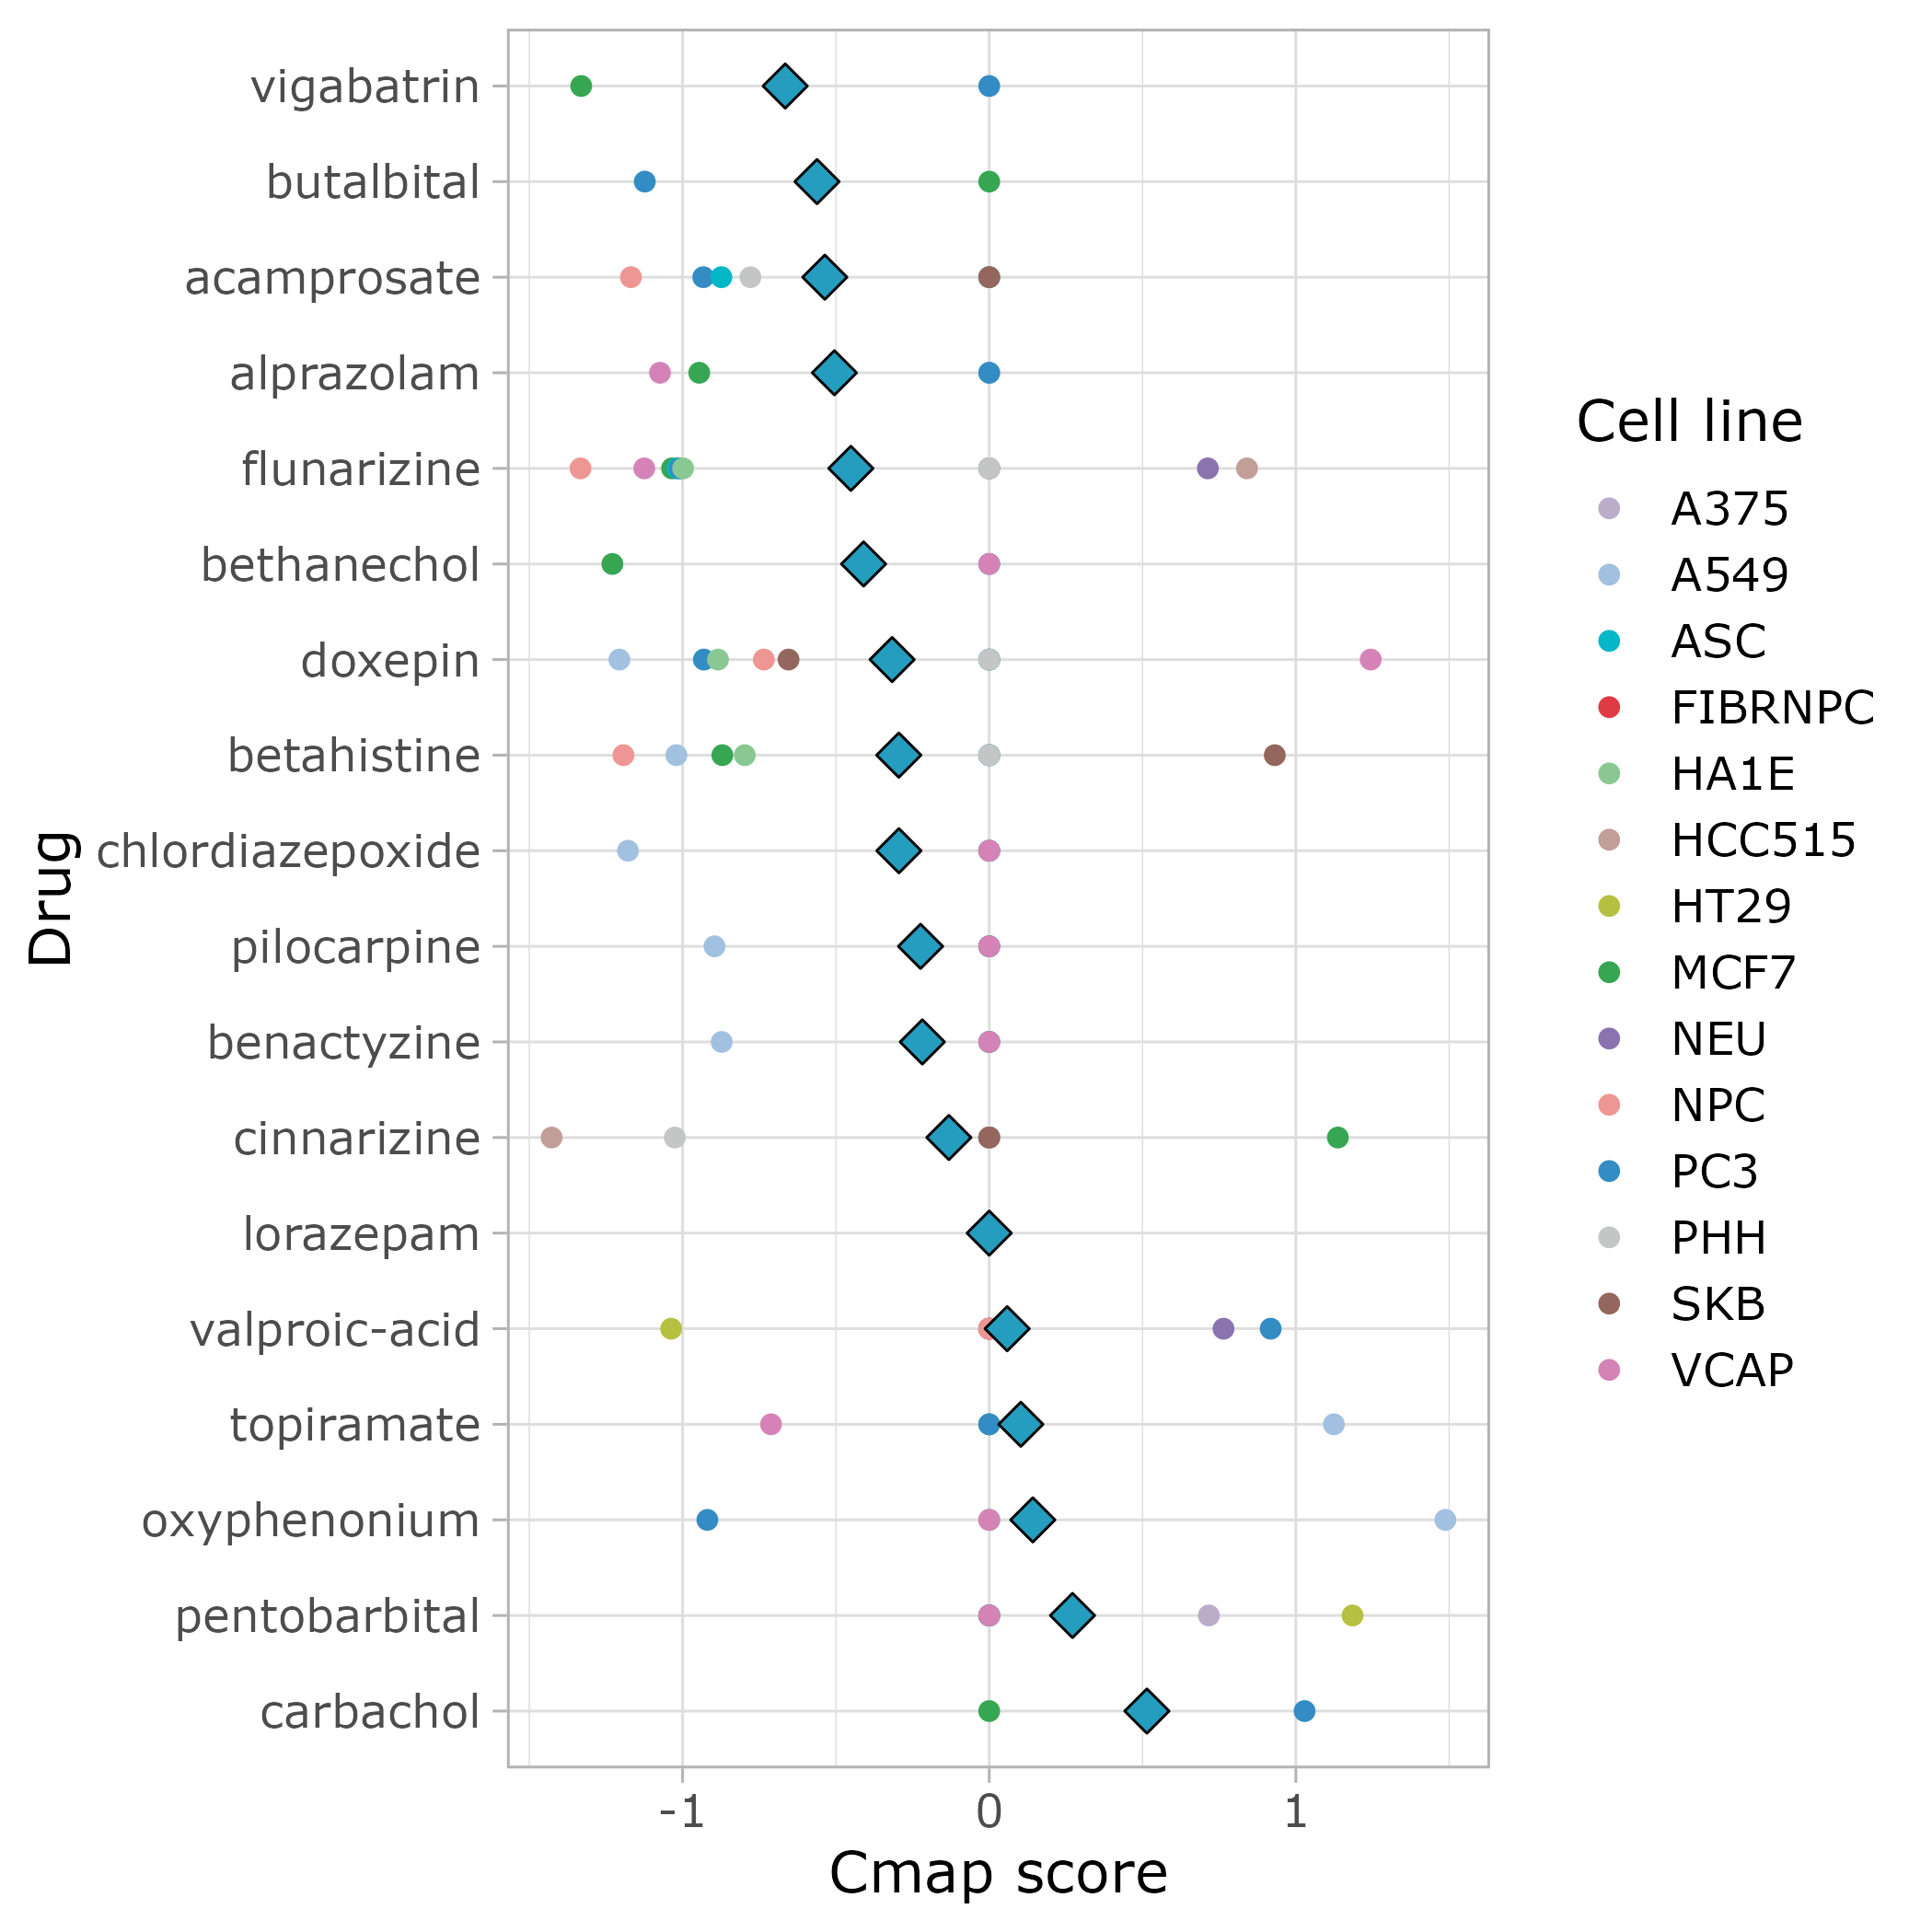

In [21]:
from IPython.display import Image
Image(filename='NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png', width = 600, height = 600)


In [24]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
library(Hmisc)


data <- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv", header = T)
head(data)
drugs <- fread("drugs.txt", header = F)
colnames(drugs)<- "pert"
merged_lincs <- merge(data, drugs, by = "pert")
write.csv(merged_lincs, "Prudencio.cerebellum.lincsmethod.DGEsBon.onlyNOMINATED.012522.csv")

#############


data <- fread("Prudencio.cerebellum.lincsmethod.DGEsBon.onlyNOMINATED.012522.csv", header = T)
data$V1 = NULL


p <- ggplot(data, aes(pert, NCS))

p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(NCS=mean(NCS))
ggplot(data = data) +
  aes((x=reorder(pert,-NCS)), y = NCS) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#259dbe") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x = "Drug",
    y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15)
  
  
ggsave("Prudencio.cerebellum.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300)

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn0939 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.16.2  on cn0939 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)


Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges

Attaching package: ‘IRanges’

The following objec

> library(tidyverse)


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.1.1     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()    masks data.table::between()
✖ dplyr::collapse()   masks IRanges::collapse()
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()       masks IRanges::desc()
✖ tidyr::expand()     masks S4Vectors::expand()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::first()      masks S4Vectors::first(), data.table::first()
✖ dplyr::lag()        masks stats::lag()
✖ dplyr::last()       masks data.table::last()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()     masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()     masks S4Vectors::rename()
✖ dplyr::select()     masks AnnotationDbi:

> library(dplyr)
> library(Hmisc)


Loading required package: lattice
Loading required package: survival
Loading required package: Formula

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:dplyr’:

    src, summarize

The following object is masked from ‘package:AnnotationDbi’:

    contents

The following object is masked from ‘package:Biobase’:

    contents

The following objects are masked from ‘package:base’:

    format.pval, units



> 
> 
> data <- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv", header = T)
> head(data)
   V1              pert     PCID cell   type trend       WTCS    WTCS_Pval
1:  1         radicicol  5311380  NEU trt_cp    up  0.5281018 2.054072e-05
2:  2     BRD-K03651937 44507986 VCAP trt_cp    up  0.5104227 2.132405e-05
3:  3     BRD-K22330909 60185012  PC3 trt_cp  down -0.4888264 2.223794e-05
4:  4   oxyphenbutazone     4641  NEU trt_cp    up  0.5040824 2.158516e-05
5:  5 BCI-hydrochloride  5475586 VCAP trt_cp    up  0.4943454 2.202035e-05
6:  6     BRD-K21374126 54651250 A375 trt_cp    up  0.4843088 2.245553e-05
      WTCS_FDR       NCS      NCSct N_upset N_downset
1: 0.000523335  1.847356  1.3680741      40        54
2: 0.000523335  1.810754  0.9445695      40        54
3: 0.000523335 -1.764001 -1.1818809      40        54
4: 0.000523335  1.763333  0.7934381      40        54
5: 0.000523335  1.753719  0.4903075      40        54
6: 0.000523335  1.741668  0.9648979      40        

Saving 7 x 7 in image


> 


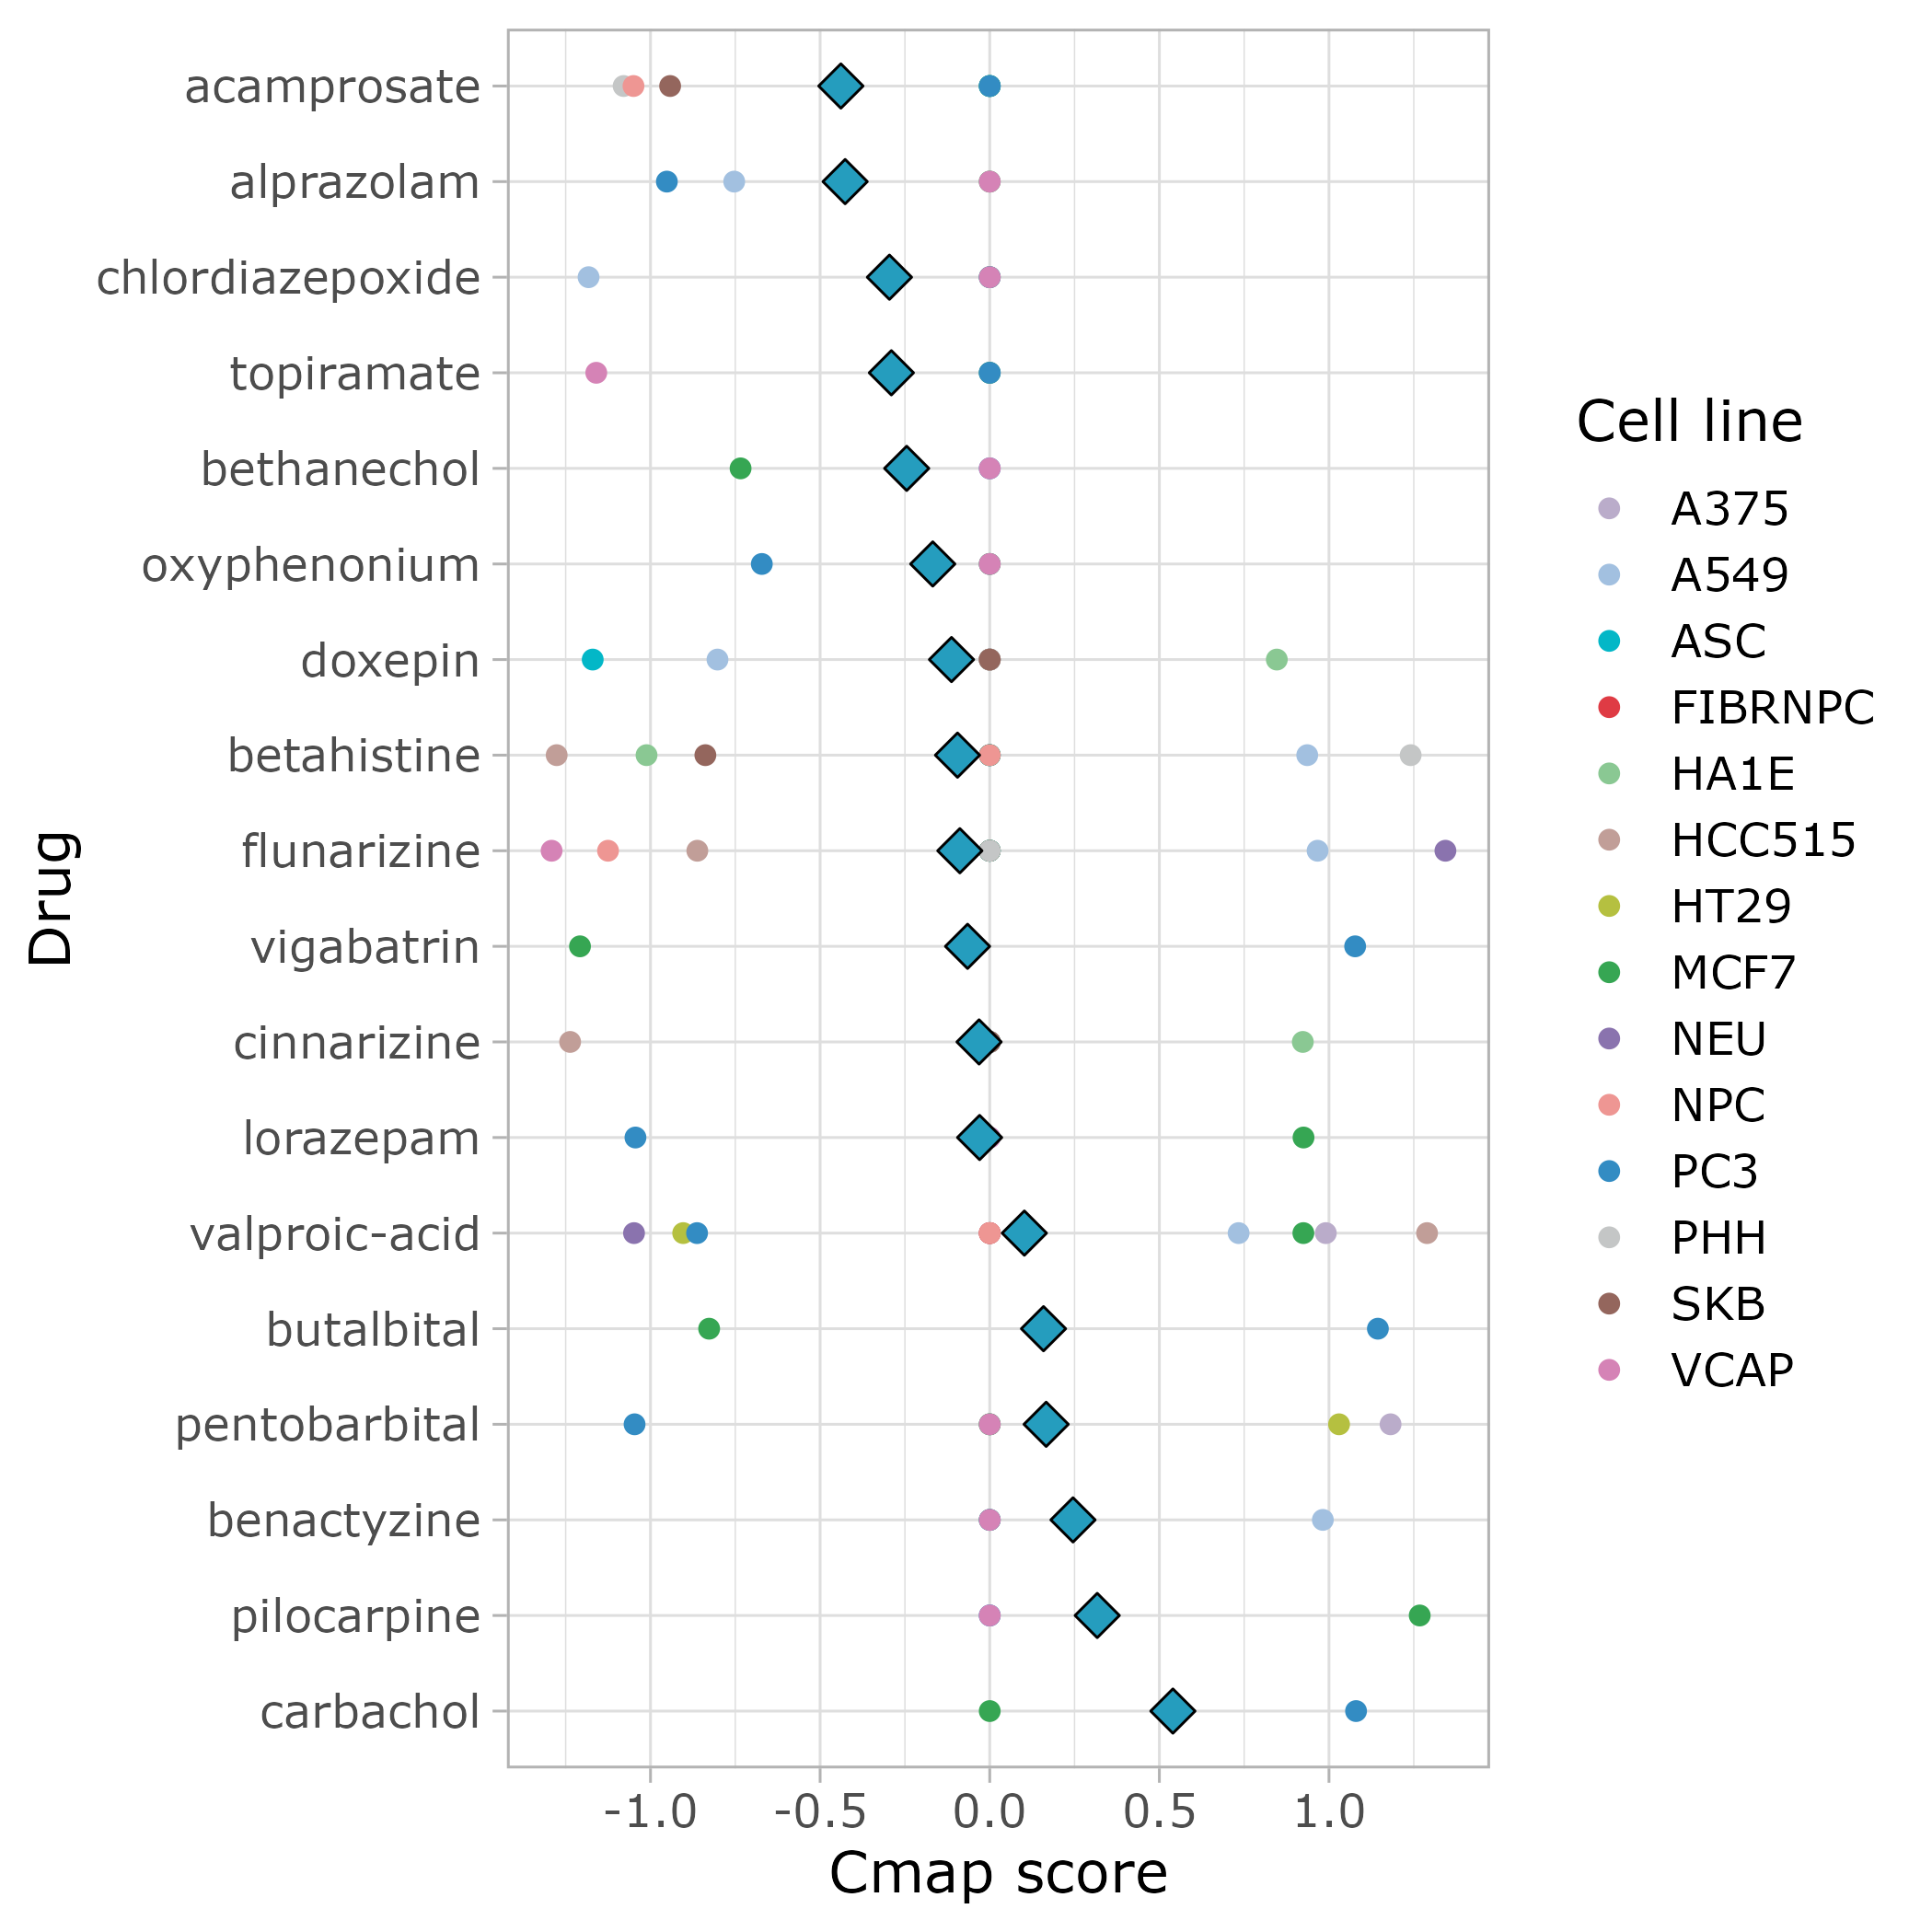

In [25]:

from IPython.display import Image
Image(filename='Prudencio.cerebellum.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png', width = 600, height = 600)

In [2]:
%%bash
echo "acamprosate
adinazolam
alprazolam
betahistine
brivaracetam
bromazepam
chlordiazepoxide
cinolazepam
clobazam
clonazepam
clotiazepam
desflurane
diazepam
enflurane
estazolam
eszopiclone
ethchlorvynol
etizolam
etomidate
fludiazepam
flurazepam
gabapentin
glutethimide
halazepam
halothane
isoflurane
levetiracetam
lorazepam
lormetazepam
meprobamate
metharbital
methoxyflurane
methyprylon
midazolam
nicotine
nitrazepam
oxazepam
pentobarbital
pitolisant
prazepam
primidone
propofol
quazepam
sevoflurane
stiripentol
talbutal
temazepam
topiramate
triazolam
varenicline
ziconotide
zonisamide" > drugs.Oct22.txt

In [3]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
df_lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.csv")
drugs <- fread("drugs.Oct22.txt", header = F)
colnames(drugs) <- "pert"
head(drugs)
merged_cmap <- merge(df_lincs, drugs, by = "pert")
write.csv(merged_cmap, "Oct22.NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.csv")


### Prudencio et al., 2015; Cerebellum 

#LINCS method using the same pertub. database and UP/DN regulated genes

df_lincs<- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv")
merged_lincs <- merge(df_lincs, drugs, by = "pert")
write.csv(merged_lincs, "Oct22.Prudencio.cerebellum.lincsmethod.DGEsFDR.onlyNOMINATED.csv")








[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn4279 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.17.1.1  on cn4279 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)


Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges

Attaching package: ‘IRanges’

The following objec

> library(tidyverse)


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.6     ✔ purrr   0.3.4
✔ tibble  3.1.8     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()    masks data.table::between()
✖ dplyr::collapse()   masks IRanges::collapse()
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()       masks IRanges::desc()
✖ tidyr::expand()     masks S4Vectors::expand()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::first()      masks S4Vectors::first(), data.table::first()
✖ dplyr::lag()        masks stats::lag()
✖ dplyr::last()       masks data.table::last()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()     masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()     masks S4Vectors::rename()
✖ dplyr::select()     masks AnnotationDbi:

> library(dplyr)
> df_lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.csv")
> drugs <- fread("drugs.Oct22.txt", header = F)
> colnames(drugs) <- "pert"
> head(drugs)
           pert
1:  acamprosate
2:   adinazolam
3:   alprazolam
4:  betahistine
5: brivaracetam
6:   bromazepam
> merged_cmap <- merge(df_lincs, drugs, by = "pert")
> write.csv(merged_cmap, "Oct22.NYGC.motorcortex.cmapmethod.lincs.DGEsBon.onlyNOMINATED.csv")
> 
> 
> ### Prudencio et al., 2015; Cerebellum 
> 
> #LINCS method using the same pertub. database and UP/DN regulated genes
> 
> df_lincs<- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv")
> merged_lincs <- merge(df_lincs, drugs, by = "pert")
> write.csv(merged_lincs, "Oct22.Prudencio.cerebellum.lincsmethod.DGEsFDR.onlyNOMINATED.csv")
> 
> 
> 
> 
> 
> 
> 


In [1]:
!pwd


/gpfs/gsfs11/users/ALS_50k/SaraSaez_ALS/2021_12_10.Transcriptomics


In [33]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
library(Hmisc)


data <- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv", header = T)
head(data)
drugs <- fread("drugs.Oct22.txt", header = F)
colnames(drugs)<- "pert"
merged_lincs <- merge(data, drugs, by = "pert")
write.csv(merged_lincs, "Oct22.Prudencio.cerebellum.lincsmethod.DGEsBon.onlyNOMINATED.csv")

#############


data <- fread("Oct22.Prudencio.cerebellum.lincsmethod.DGEsBon.onlyNOMINATED.csv", header = T)
data$V1 = NULL


p <- ggplot(data, aes(pert, NCS))

p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(NCS=mean(NCS))
ggplot(data = data) +
  aes((x=reorder(pert,-NCS)), y = NCS) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#ac7fb1") + scale_color_manual(values = cbp1) + coord_flip() +
 labs(x=NULL, y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15) + theme(axis.text.y = element_text(size = 15)) + theme(axis.title = element_text(size = 20)) +
theme(legend.position="bottom")
  
  
  
  
ggsave("Oct22.Prudencio.cerebellum.lincsmethod.lincs.DGEsBon.onlyNOMINATED.bigger.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300,
    width = 4, height = 6)

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn4298 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.17.1.1  on cn4298 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)


Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges

Attaching package: ‘IRanges’

The following objec

> library(tidyverse)


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.6     ✔ purrr   0.3.4
✔ tibble  3.1.8     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()    masks data.table::between()
✖ dplyr::collapse()   masks IRanges::collapse()
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()       masks IRanges::desc()
✖ tidyr::expand()     masks S4Vectors::expand()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::first()      masks S4Vectors::first(), data.table::first()
✖ dplyr::lag()        masks stats::lag()
✖ dplyr::last()       masks data.table::last()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()     masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()     masks S4Vectors::rename()
✖ dplyr::select()     masks AnnotationDbi:

> library(dplyr)
> library(Hmisc)


Loading required package: lattice
Loading required package: survival
Loading required package: Formula

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:dplyr’:

    src, summarize

The following object is masked from ‘package:AnnotationDbi’:

    contents

The following object is masked from ‘package:Biobase’:

    contents

The following objects are masked from ‘package:base’:

    format.pval, units



> 
> 
> data <- fread("Prudencio.cerebellum..lincsmethod.DGEsFDR.ALL.csv", header = T)
> head(data)
   V1              pert     PCID cell   type trend       WTCS    WTCS_Pval
1:  1         radicicol  5311380  NEU trt_cp    up  0.5281018 2.054072e-05
2:  2     BRD-K03651937 44507986 VCAP trt_cp    up  0.5104227 2.132405e-05
3:  3     BRD-K22330909 60185012  PC3 trt_cp  down -0.4888264 2.223794e-05
4:  4   oxyphenbutazone     4641  NEU trt_cp    up  0.5040824 2.158516e-05
5:  5 BCI-hydrochloride  5475586 VCAP trt_cp    up  0.4943454 2.202035e-05
6:  6     BRD-K21374126 54651250 A375 trt_cp    up  0.4843088 2.245553e-05
      WTCS_FDR       NCS      NCSct N_upset N_downset
1: 0.000523335  1.847356  1.3680741      40        54
2: 0.000523335  1.810754  0.9445695      40        54
3: 0.000523335 -1.764001 -1.1818809      40        54
4: 0.000523335  1.763333  0.7934381      40        54
5: 0.000523335  1.753719  0.4903075      40        54
6: 0.000523335  1.741668  0.9648979      40        

In [3]:
!pwd

/gpfs/gsfs11/users/ALS_50k/SaraSaez_ALS/2021_12_10.Transcriptomics


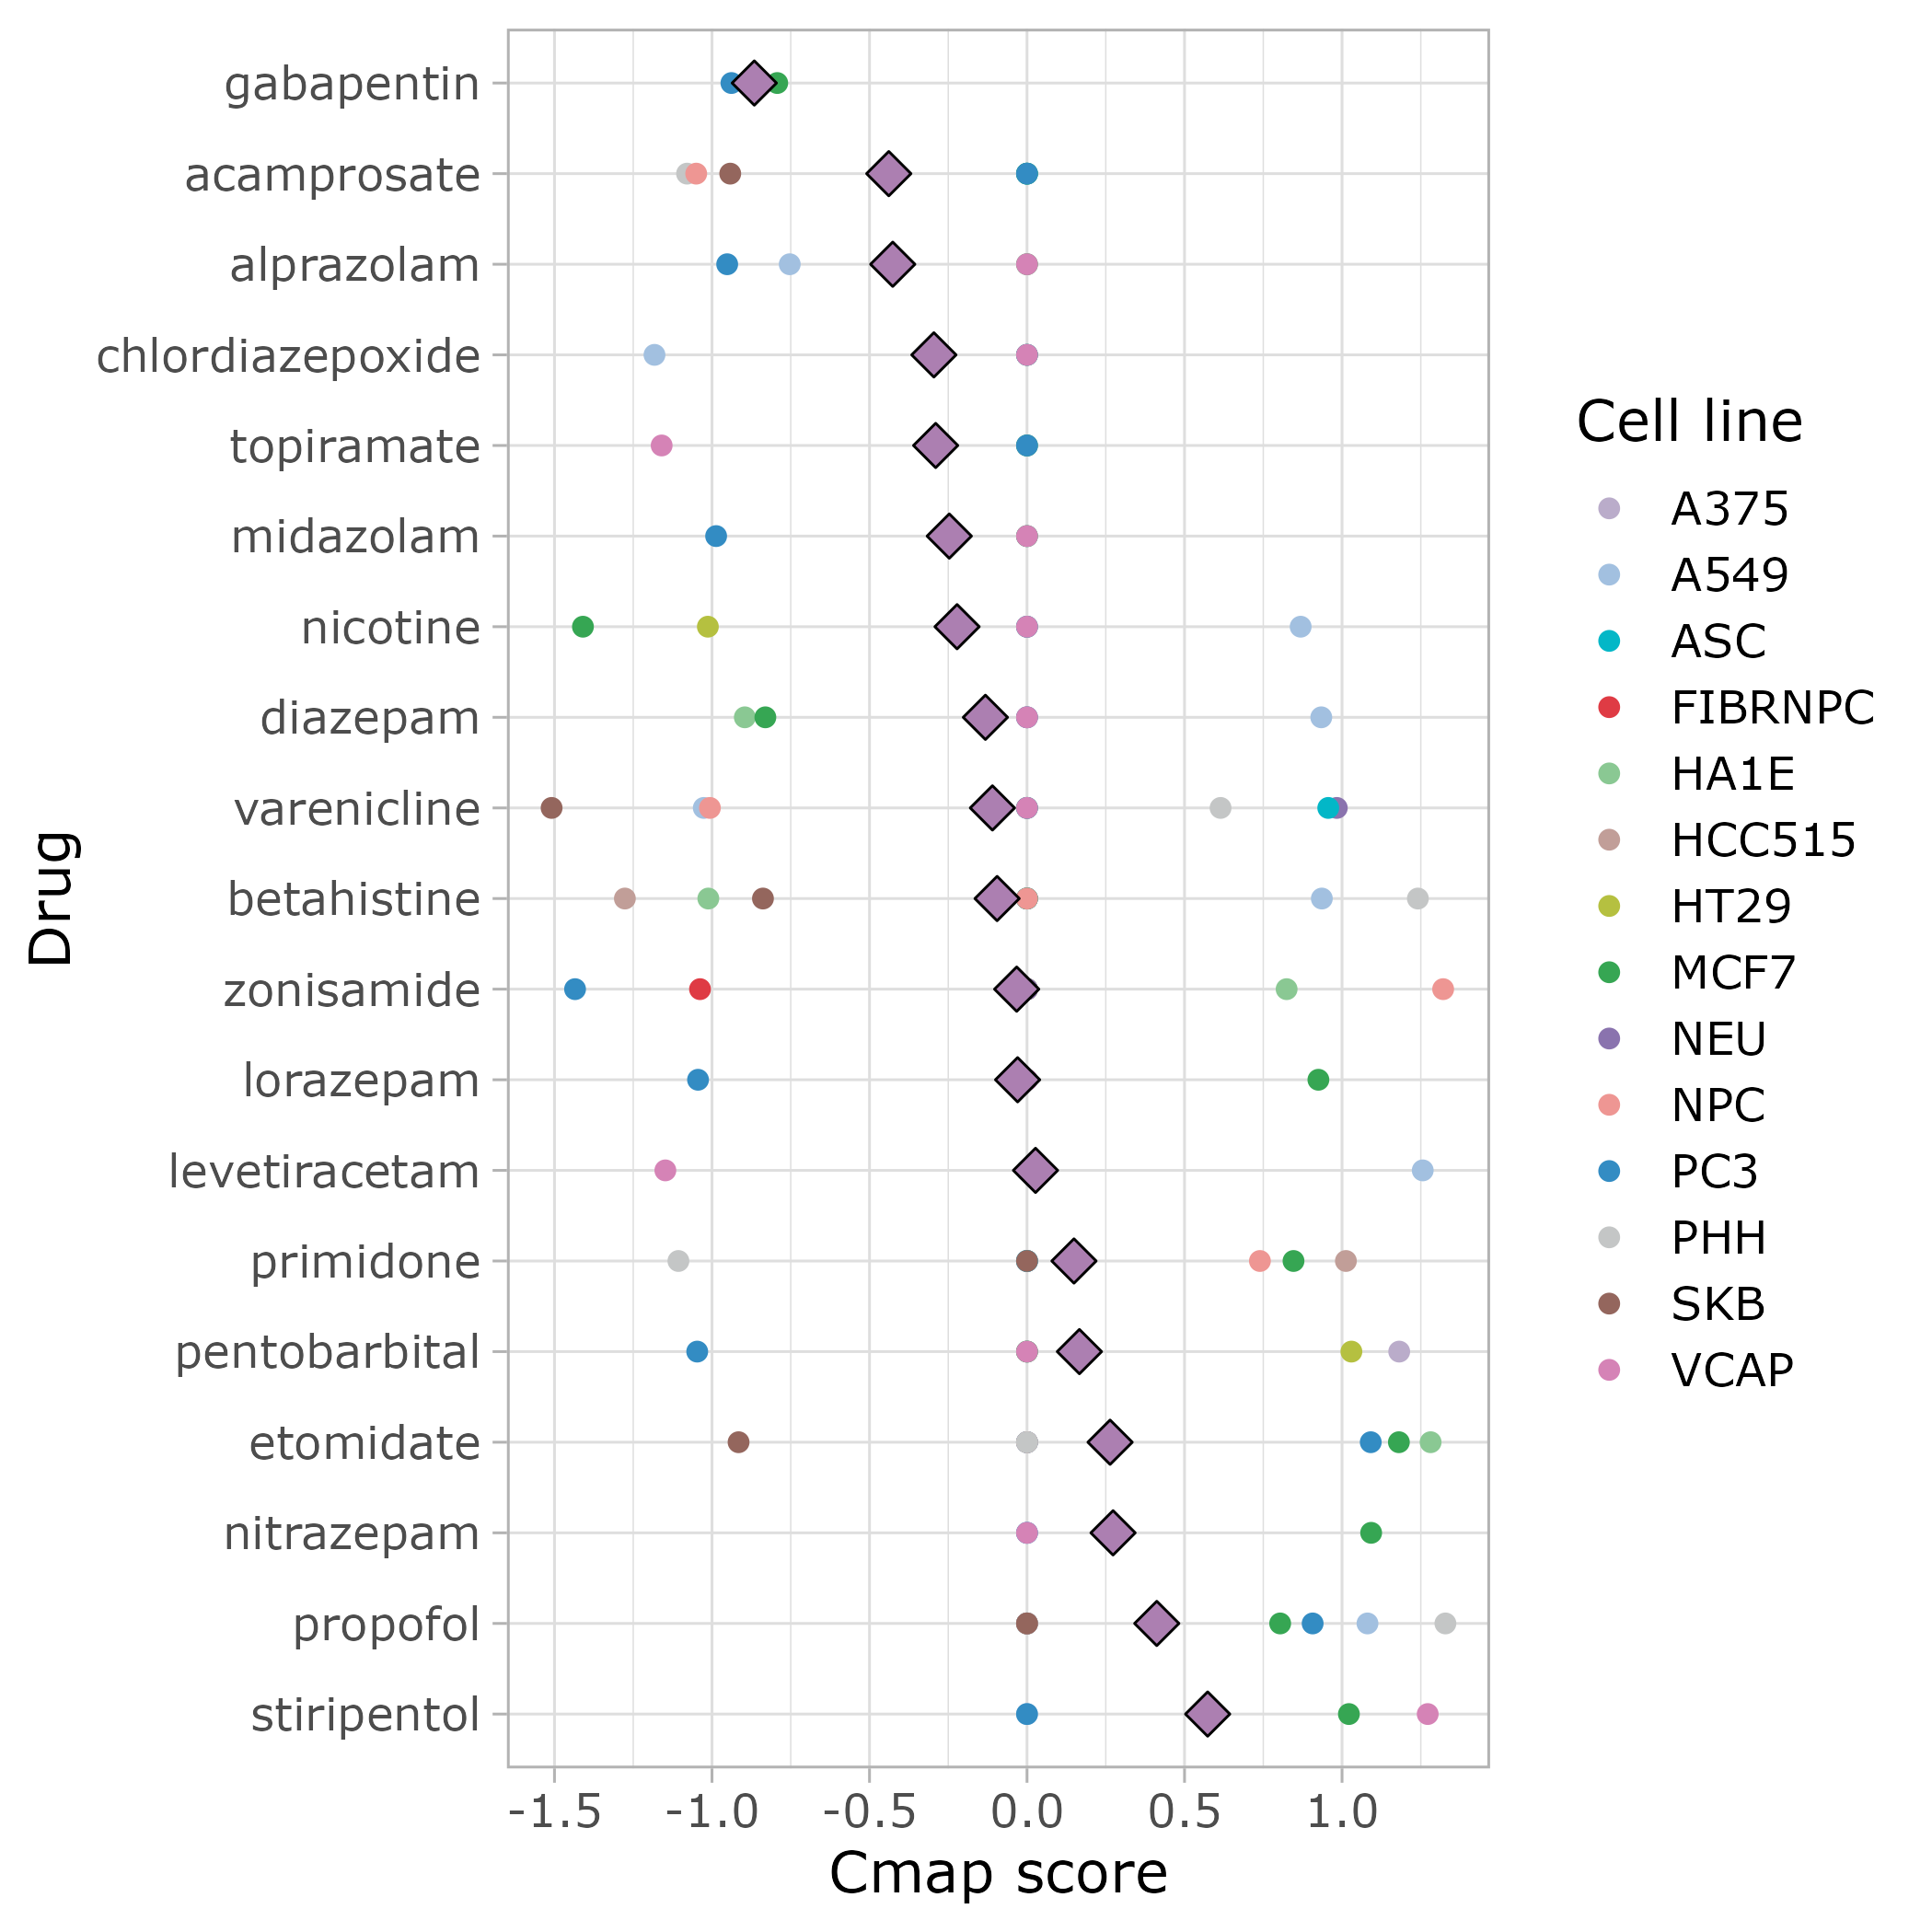

In [11]:

from IPython.display import Image
Image(filename='Oct22.Prudencio.cerebellum.lincsmethod.lincs.DGEsBon.onlyNOMINATED.png', width = 600, height = 600)

In [30]:
%%bash 

module load R/4.1.0
R --vanilla --no-save
library(data.table)
library(mygene)
library(tidyverse)
library(dplyr)
library(Hmisc)


lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.012522.csv", header = T)

drugs <- fread("drugs.Oct22.txt", header = F)
colnames(drugs)<- "pert"
merged_lincs <- merge(lincs, drugs, by = "pert")
write.csv(merged_lincs, "Oct22.NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv")
head(merged_lincs)
#############

data <- fread("Oct22.NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv", header = T)
data$V1 = NULL


p <- ggplot(data, aes(pert, NCS))

p + geom_point(aes(colour = cell))

library(RColorBrewer)
cbp1 <- c("#baacca", "#a2c0e0", "#03b7c7", "#df3b44",
          "#8ac893", "#c19e98", "#b5c040", "#36a653", "#8a73ae", "#ee9693",
          "#338cc3", "#c4c6c6", "#94665d", "#d583b6")
p + scale_color_manual(values = cbp1)
display.brewer.all()
df_means <- data %>% group_by(pert) %>% summarise(NCS=mean(NCS))
ggplot(data = data) +
  aes((x=reorder(pert,-NCS)), y = NCS) +
  geom_point(aes(colour = cell),  size = 2) + 
  geom_point(data=df_means, 
             col="black",  
             size = 4,
             shape = 23,
             fill = "#259dbe") + scale_color_manual(values = cbp1) + coord_flip() +
  labs(x=NULL, y = "Cmap score",
    colour = "Cell line"
  ) +
  theme_light(15) + theme(axis.text.y = element_text(size = 15)) + theme(axis.title = element_text(size = 20)) +
theme(legend.position="bottom")
  
  
ggsave("Oct22.NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.bigger.png",
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  dpi = 300,
  width = 4, height = 6)

[+] Loading gcc  9.2.0  ... 
[+] Loading GSL 2.6 for GCC 9.2.0 ...
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading openmpi 4.0.5  for GCC 9.2.0 
[+] Loading ImageMagick  7.0.8  on cn4298 
[+] Loading HDF5  1.10.4 
[-] Unloading gcc  9.2.0  ... 
[+] Loading gcc  9.2.0  ... 
[+] Loading NetCDF 4.7.4_gcc9.2.0 
[+] Loading pandoc  2.17.1.1  on cn4298 
[+] Loading pcre2 10.21  ... 
[+] Loading R 4.1.0 



R version 4.1.0 (2021-05-18) -- "Camp Pontanezen"
Copyright (C) 2021 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(data.table)
> library(mygene)


Loading required package: GenomicFeatures
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors
Loading required package: stats4

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges

Attaching package: ‘IRanges’

The following objec

> library(tidyverse)


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──
✔ ggplot2 3.3.6     ✔ purrr   0.3.4
✔ tibble  3.1.8     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()    masks data.table::between()
✖ dplyr::collapse()   masks IRanges::collapse()
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::desc()       masks IRanges::desc()
✖ tidyr::expand()     masks S4Vectors::expand()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::first()      masks S4Vectors::first(), data.table::first()
✖ dplyr::lag()        masks stats::lag()
✖ dplyr::last()       masks data.table::last()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()     masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()     masks S4Vectors::rename()
✖ dplyr::select()     masks AnnotationDbi:

> library(dplyr)
> library(Hmisc)


Loading required package: lattice
Loading required package: survival
Loading required package: Formula

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:dplyr’:

    src, summarize

The following object is masked from ‘package:AnnotationDbi’:

    contents

The following object is masked from ‘package:Biobase’:

    contents

The following objects are masked from ‘package:base’:

    format.pval, units



> 
> 
> lincs <- fread("NYGC.motorcortex.lincsmethod.DGEsBon.ALL.012522.csv", header = T)
> 
> drugs <- fread("drugs.Oct22.txt", header = F)
> colnames(drugs)<- "pert"
> merged_lincs <- merge(lincs, drugs, by = "pert")
> write.csv(merged_lincs, "Oct22.NYGC.motorcortex.lincsmethod.DGEsBon.onlyNOMINATED.csv")
> head(merged_lincs)
          pert    V1     PCID cell   type trend       WTCS    WTCS_Pval
1: acamprosate  2881 73707392  NPC trt_cp  down -0.3592972 2.793886e-05
2: acamprosate  9663 73707392  PC3 trt_cp  down -0.2763945 4.000609e-03
3: acamprosate 11563 73707392  ASC trt_cp  down -0.2693191 6.882011e-03
4: acamprosate 14007 73707392  PHH trt_cp  down -0.2567143 1.614368e-02
5: acamprosate 36228 73707392 A549 trt_cp  down  0.0000000 3.144514e-01
6: acamprosate 36566 73707392 MCF7 trt_cp  down  0.0000000 3.144514e-01
       WTCS_FDR        NCS      NCSct N_upset N_downset
1: 0.0004191783 -1.1683867 -0.8747677      50        34
2: 0.0183649992 -0.9325605 -0.8747677      50        3

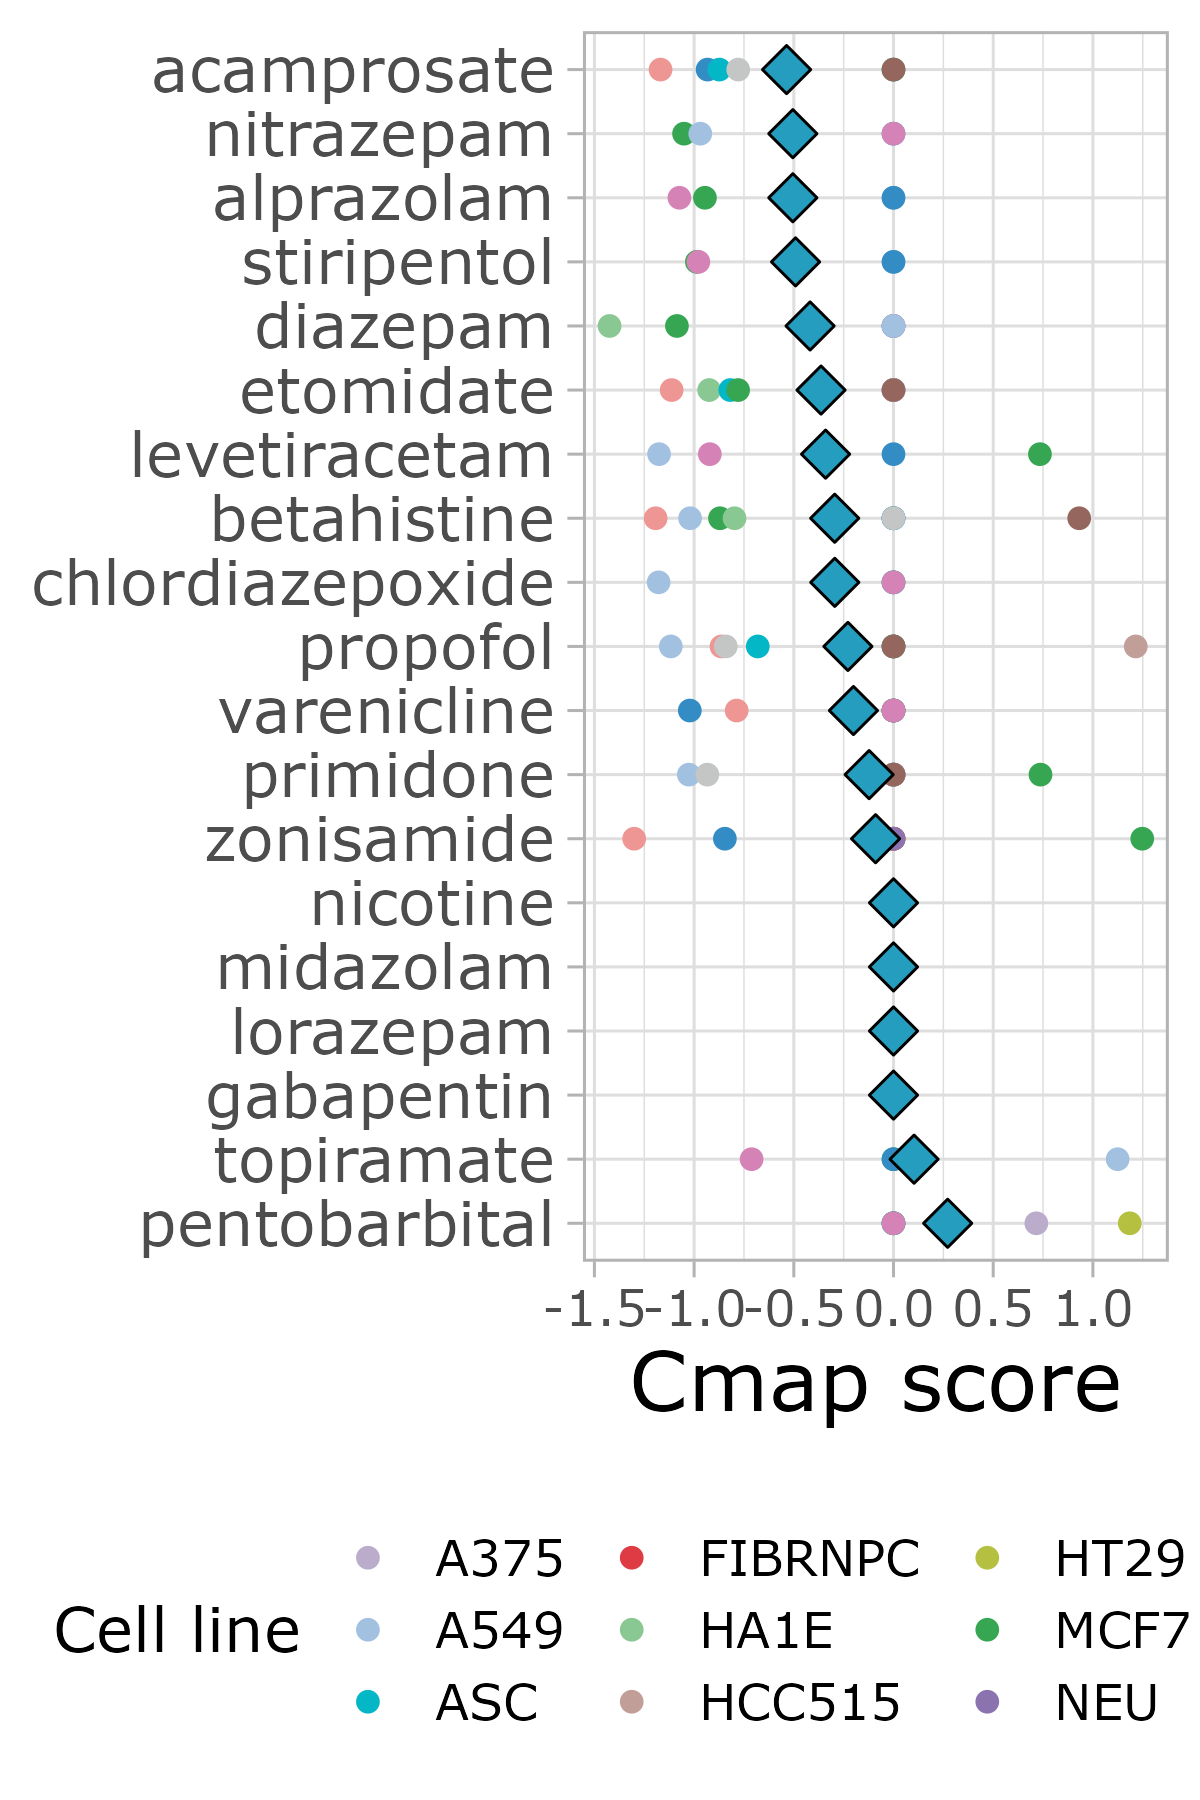

In [31]:

from IPython.display import Image
Image(filename='Oct22.NYGC.motorcortex.lincsmethod.lincs.DGEsBon.onlyNOMINATED.bigger.png', width = 600, height = 600)